# 🎧 Análise de Dados Pessoais do Spotify

**Autoria:** Vivian Yamassaki (criado com auxílio do Gemini Flash 3.8)

**Objetivo:** Este notebook tem como objetivo processar o histórico de reprodução estendido do Spotify (arquivos JSON) para validar as métricas de tempo ouvido, dispositivos, top faixas, comportamento de skips e tendências semanais, além de explorar padrões comportamentais (cronotipos, maratonas, skip rate) e gerar visualizações interativas.

**Como baixar seus dados no Spotify:** Acesse a aba [Privacidade da conta](https://www.spotify.com/br-pt/account/privacy/) e faça a solicitação para poder baixar seus dados (o envio dos dados não é imediato e pode demorar alguns dias). Após baixar seus dados, coloque-os na pasta `spotify`, que é o padrão que o notebook usará para encontrá-los :)



## 1. Configuração e Importação de Bibliotecas
Centralização de todos os pacotes utilizados no projeto, evitando importações redundantes ao longo das células.

In [1]:
import os
import glob
import json
import random
import webbrowser
from datetime import datetime, timedelta

# Manipulação e computação científica
import pandas as pd
import numpy as np

# Visualização de dados estática e interativa
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker # Importa ticker explicitamente
import seaborn as sns
import matplotlib.animation as animation
from matplotlib.ticker import FuncFormatter

# Configurações estéticas globais
sns.set_style('whitegrid', {'axes.facecolor': 'white', 'figure.facecolor': 'white'})
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
pd.set_option('display.max_columns', None)

# Markdown para geração de relatório
import markdown
from IPython.display import display, HTML, Markdown, Image

# Paletas de cores personalizadas
PALETA_SPOTIFY = ['#1DB954', '#38bdf8', '#a855f7', '#f97316', '#ef4444', '#facc15']
PALETA_PASTEL = ['#ffb3ba', '#baffc9', '#bae1ff', '#cbaacb', '#ffdfba', '#fcc2eb']

# Variável contendo o mês e ano que será analisado ao longo do notebook
MES_ANALISADO = 8
ANO_ANALISADO = 2026

print("✅ Bibliotecas carregadas e ambiente configurado com sucesso!")

✅ Bibliotecas carregadas e ambiente configurado com sucesso!


In [2]:
# Declaração inicial para o relatório de saída com as métricas em formato markdown
report_content_md = []
report_content_md.append(f"# Relatório de Análise Spotify - Mês {MES_ANALISADO}/{ANO_ANALISADO}")
report_content_md.append("\n--- ")

## 2. Ingestão, Padronização e Fuso Horário
Normalização das estruturas dos arquivos JSON (`Streaming_History_Audio_*.json` ou `endsong_*.json`) e conversão dos carimbos de data/hora de UTC para o horário de Brasília (`America/Sao_Paulo`).

In [3]:
def ajustar_fuso_horario(serie_temporal: pd.Series) -> pd.Series:
    """Converte timestamps para datetime e ajusta para o fuso de Brasília."""
    ts = pd.to_datetime(serie_temporal)
    if ts.dt.tz is None:
        ts = ts.dt.tz_localize('UTC')
    return ts.dt.tz_convert('America/Sao_Paulo')

def carregar_dados_spotify(pasta_dados: str = ".") -> pd.DataFrame:
    """
    Lê todos os JSONs de streaming do diretório e padroniza as colunas
    em um esquema único e limpo.
    """
    arquivos = glob.glob(os.path.join(pasta_dados, "*Streaming*Audio*.json")) + \
               glob.glob(os.path.join(pasta_dados, "*endsong*.json"))

    if not arquivos:
        print("⚠️ Nenhum arquivo JSON real encontrado. Gerando dados sintéticos para demonstração...")
        return gerar_dados_mock()

    dfs = []
    for arq in arquivos:
        try:
            with open(arq, 'r', encoding='utf-8') as f:
                dados = json.load(f)
                if isinstance(dados, list) and dados:
                    # Junta as listas de dicionários diretamente
                    dfs.extend(dados)
        except Exception as e:
            print(f"Erro ao ler {arq}: {e}")

    # Cria o DataFrame final de uma vez só (evita o pd.concat e o warning)
    if dfs:
        df_bruto = pd.DataFrame(dfs)
    else:
        df_bruto = pd.DataFrame()

    df = pd.DataFrame()

    # Mapeamento do formato estendido (LGPD) ou simples
    if 'ts' in df_bruto.columns:
        df['ts_utc'] = pd.to_datetime(df_bruto['ts'])
        df['artista'] = df_bruto['master_metadata_album_artist_name']
        df['musica'] = df_bruto['master_metadata_track_name']
        df['album'] = df_bruto.get('master_metadata_album_album_name', None)
        df['ms_tocados'] = df_bruto['ms_played']
        df['plataforma'] = df_bruto.get('platform', 'desconhecido')
        df['motivo_inicio'] = df_bruto.get('reason_start', None)
        df['motivo_fim'] = df_bruto.get('reason_end', None)
        df['pulou'] = df_bruto.get('skipped', False)
        df['shuffle'] = df_bruto.get('shuffle', False)
        df['uri_faixa'] = df_bruto.get('spotify_track_uri', None)
    else:
        df['ts_utc'] = pd.to_datetime(df_bruto['endTime'])
        df['artista'] = df_bruto['artistName']
        df['musica'] = df_bruto['trackName']
        df['album'] = None
        df['ms_tocados'] = df_bruto['msPlayed']
        df['plataforma'] = 'desconhecido'
        df['motivo_inicio'] = None
        df['motivo_fim'] = None
        df['pulou'] = False
        df['shuffle'] = False
        df['uri_faixa'] = None

    # Limpeza de podcasts e registros vazios
    df = df.dropna(subset=['artista', 'musica']).copy()

    # Ajuste de tempo e variáveis analíticas
    df['ts'] = ajustar_fuso_horario(df['ts_utc'])
    df['data'] = df['ts'].dt.date
    df['ano'] = df['ts'].dt.year
    df['mes'] = df['ts'].dt.month
    df['ano_mes'] = df['ts'].dt.tz_localize(None).dt.to_period('M')
    df['hora'] = df['ts'].dt.hour
    df['semana'] = df['ts'].dt.isocalendar().week
    df['dia'] = df['ts'].dt.day
    df['dia_semana'] = df['ts'].dt.day_name()
    df['minutos_tocados'] = df['ms_tocados'] / 60000.0

    return df

def gerar_dados_mock(num_registros: int = 500) -> pd.DataFrame:
    """Gera massa de dados simulada para testes locais."""
    np.random.seed(42)
    datas = pd.date_range(start="2026-07-01", end="2026-08-31", freq='h')
    catalogo = {
        'Anitta': ['Tudo Isso', 'Ponta Do Pé', 'Ternura', 'Varias Quejas',],
        'Gilsons': ['BEM ME QUER', 'Várias Queixas', 'Proposta', 'Devagarinho', 'Love Love'],
        'John Mayer': ['New Light', 'Gravity'],
        'Dua Lipa': ['Training Season', 'Levitating', 'Dance The Night'],
        'Liniker': ['POTE DE OURO']
    }

    dados = []
    for dt in datas[:num_registros]:
        art = np.random.choice(list(catalogo.keys()), p=[0.40, 0.25, 0.15, 0.10, 0.10])
        trk = np.random.choice(catalogo[art])
        ms = np.random.randint(15000, 240000)
        motivo_fim = 'trackdone' if ms > 160000 else np.random.choice(['fwdbtn', 'endplay', 'logout'], p=[0.7, 0.2, 0.1])

        dados.append({
            'ts': dt.isoformat() + 'Z',
            'master_metadata_album_artist_name': art,
            'master_metadata_track_name': trk,
            'master_metadata_album_album_name': 'Álbum Demo',
            'ms_played': ms,
            'platform': np.random.choice(['android', 'windows', 'osx'], p=[0.8, 0.15, 0.05]),
            'reason_start': np.random.choice(['trackdone', 'clickrow', 'fwdbtn'], p=[0.7, 0.2, 0.1]),
            'reason_end': motivo_fim,
            'skipped': motivo_fim == 'fwdbtn',
            'shuffle': True,
            'spotify_track_uri': f'spotify:track:demo_{hash(trk)}'
        })
    df_raw = pd.DataFrame(dados)
    df_raw.to_json('Streaming_History_Audio_2026.json', orient='records')
    return carregar_dados_spotify('.')

# Carga inicial do dataset
df_historico = carregar_dados_spotify('drive/MyDrive/spotify/Spotify Extended Streaming History')
print(f"📊 Total de execuções carregadas: {len(df_historico):,}")
df_historico.head(3)

📊 Total de execuções carregadas: 83,550


,ts_utc,artista,musica,album,ms_tocados,plataforma,motivo_inicio,motivo_fim,pulou,shuffle,uri_faixa,ts,data,ano,mes,ano_mes,hora,semana,dia,dia_semana,minutos_tocados
0,2016-01-02 01:28:31+00:00,Wham!,Last Christmas,Christmas Hits,0,Windows 7 (6.1.7601; x64; SP1; S),appload,endplay,True,True,spotify:track:0QPYn15U8IQHKcH2LDfrek,2016-01-01 23:28:31-02:00,2016-01-01,2016,1,2016-01,23,53,1,Friday,0.0
1,2016-01-04 18:02:29+00:00,Wham!,Last Christmas,Christmas Hits,0,Windows 7 (6.1.7601; x64; SP1; S),appload,endplay,True,True,spotify:track:0QPYn15U8IQHKcH2LDfrek,2016-01-04 16:02:29-02:00,2016-01-04,2016,1,2016-01,16,1,4,Monday,0.0
2,2016-01-04 19:22:32+00:00,Wham!,Last Christmas,Christmas Hits,0,Windows 7 (6.1.7601; x64; SP1; S),appload,endplay,True,True,spotify:track:0QPYn15U8IQHKcH2LDfrek,2016-01-04 17:22:32-02:00,2016-01-04,2016,1,2016-01,17,1,4,Monday,0.0


### 2.1 Filtragem do mês a ser analisado

In [4]:
def filtrar_mes(df: pd.DataFrame, ano: int, mes: int) -> pd.DataFrame:
    """Filtra os dados para um mês e ano específicos."""
    periodo = pd.Period(f"{ano}-{mes:02d}", freq='M')
    return df[df['ano_mes'] == periodo].copy()

In [5]:
# Filtra os dados somente do mês analisado
df = filtrar_mes(df_historico, ANO_ANALISADO, MES_ANALISADO)

In [6]:
# Calcula o mês anterior tratando a virada de ano
if MES_ANALISADO == 1:
    MES_ANTERIOR = 12
    ANO_ANTERIOR = ANO_ANALISADO - 1
else:
    MES_ANTERIOR = MES_ANALISADO - 1
    ANO_ANTERIOR = ANO_ANALISADO

# Aplica o filtro na outra base que será usada em algumas análises
df_mes_anterior = filtrar_mes(df_historico, ANO_ANTERIOR, MES_ANTERIOR)

In [7]:
# Carga inicial do dataset do mês analisado
print(f"📊 Total de execuções carregadas no mês analisado: {len(df):,}")
df.head(3)

📊 Total de execuções carregadas no mês analisado: 1,123


,ts_utc,artista,musica,album,ms_tocados,plataforma,motivo_inicio,motivo_fim,pulou,shuffle,uri_faixa,ts,data,ano,mes,ano_mes,hora,semana,dia,dia_semana,minutos_tocados
60579,2026-08-01 12:51:43+00:00,John Mayer,New Light,Sob Rock,217427,android,clickrow,trackdone,False,True,spotify:track:4T6FWA703h6H7zk1FoSARw,2026-08-01 09:51:43-03:00,2026-08-01,2026,8,2026-08,9,31,1,Saturday,3.623783
60580,2026-08-01 12:53:49+00:00,Gilsons,Se A Vida Pede,Eu Vejo Luz Em Maior Proporção Do Que Eu Vejo ...,125255,android,trackdone,trackdone,False,True,spotify:track:4gTuqFIERehs53UpG07xU9,2026-08-01 09:53:49-03:00,2026-08-01,2026,8,2026-08,9,31,1,Saturday,2.087583
60581,2026-08-01 12:56:54+00:00,Gilsons,BEM ME QUER,BEM ME QUER / MINHA FLOR,185217,android,trackdone,trackdone,False,True,spotify:track:3p9kP1UGKkpmHoO8QZrbMT,2026-08-01 09:56:54-03:00,2026-08-01,2026,8,2026-08,9,31,1,Saturday,3.086950


## 3. Ranking Mensal e Cápsula Sonora
Cálculo dos totais de minutos e horas escutadas, média diária e artistas mais ouvidos. Reproduz as métricas existentes na Cápsula Sonora do Spotify e cria outras métricas complementares.

In [8]:
def aplicar_regra_stream_oficial(df: pd.DataFrame) -> pd.DataFrame:
    """
    O Spotify contabiliza como 'Stream' oficial as reproduções
    com pelo menos 30 segundos (30.000 ms).
    """
    return df[df['ms_tocados'] >= 30000].copy()

def calcular_metricas_tempo(df_atual: pd.DataFrame, df_anterior: pd.DataFrame = None):
    """
    Reproduz o card: 'Você ouviu X minutos de música esse mês'
    e calcula a variação percentual em relação ao mês anterior.
    """
    minutos_totais = df_atual['minutos_tocados'].sum()
    dias_no_mes = df_atual['ts'].dt.days_in_month.iloc[0] if not df_atual.empty else 30

    # Média diária considerando os dias do mês
    media_diaria = minutos_totais / dias_no_mes

    # Formatação em dias, horas e minutos (ex: 1d 23h 55min)
    tempo_delta = timedelta(minutes=float(minutos_totais))
    dias = tempo_delta.days
    horas, resto = divmod(tempo_delta.seconds, 3600)
    minutos = resto // 60

    print("=" * 60)
    print("⏱️  CÁPSULA SONORA: TEMPO OUVIDO")
    print("=" * 60)
    print(f"Total Ouvido: {int(round(minutos_totais)):,} minutos ({dias}d {horas}h {minutos}min)".replace(',', '.'))
    print(f"Média Diária: {int(round(media_diaria))} min/dia")

    report_content_md.append("\n## ⏱️  CÁPSULA SONORA: TEMPO OUVIDO")
    report_content_md.append(f"\nTotal Ouvido: {int(round(minutos_totais)):,} minutos ({dias}d {horas}h {minutos}min)".replace(',', '.'))
    report_content_md.append(f"\nMédia Diária: {int(round(media_diaria))} min/dia")

    if df_anterior is not None and not df_anterior.empty:
        minutos_ant = df_anterior['minutos_tocados'].sum()
        var_pct = ((minutos_totais - minutos_ant) / minutos_ant) * 100
        sinal = "+" if var_pct > 0 else ""
        print(f"\nComparação com mês anterior: {int(round(minutos_ant))} min ({sinal}{var_pct:.0f}%)")
        report_content_md.append(f"\nComparação com mês anterior: {int(round(minutos_ant))} min ({sinal}{var_pct:.0f}%)")

    print("=" * 60 + "\n")

def plotar_grafico_diario(df_atual: pd.DataFrame):
    """
    Reproduz o gráfico de barras verticais com a linha de média diária
    exibido na tela de 'Tempo ouvido'.
    """
    dias_no_mes = pd.Period(f"{ANO_ANALISADO}-{MES_ANALISADO:02d}").days_in_month
    dias_todos = pd.DataFrame({'dia': range(1, dias_no_mes + 1)})

    # Agrupa minutos por dia
    agrupado_dia = df_atual.groupby('dia')['minutos_tocados'].sum().reset_index()
    dados_completos = dias_todos.merge(agrupado_dia, on='dia', how='left').fillna(0)

    media_diaria = dados_completos['minutos_tocados'].mean()
    pico_max = dados_completos['minutos_tocados'].max()

    # Gráfico: Evolução Diária do Tempo Ouvido
    plt.figure(figsize=(14, 5))
    sns.lineplot(data=dados_completos, x='dia', y='minutos_tocados', color='#1DB954', linewidth=2, marker='o')
    plt.title('Minutos Tocados por Dia', fontsize=14, color='black')
    plt.xlabel('Data', color='black')
    plt.ylabel('Minutos Totais', color='black')
    plt.xticks(rotation=45, color='black')
    plt.yticks(color='black')
    plt.axhline(media_diaria, color='gray', linestyle='--', label=f'Média: {media_diaria:.0f} min')
    plt.legend()
    plt.tight_layout()
    sns.despine(left=True, bottom=True)
    plt.savefig("daily_evolution.png")
    plt.show()
    print("Gráfico 'daily_evolution.png' salvo.")
    report_content_md.append("\n### Gráfico: Evolução Diária do Tempo Ouvido")
    report_content_md.append(f"<img src='daily_evolution.png' alt='Evolução Diária do Tempo Ouvido' style='width:600px; max-width:100%;'>")


def calcular_artistas_mais_ouvidos(df_atual: pd.DataFrame, df_anterior: pd.DataFrame = None, top_n: int = 5):
    """
    Reproduz o card:
    - 'Você ouviu X artistas esse mês' (+ comparação)
    - Top 5 Artistas por volume de escuta
    """
    df_streams = aplicar_regra_stream_oficial(df_atual)

    # Total de artistas únicos
    artistas_unicos = df_atual['artista'].nunique()
    print("=" * 60)
    print("🎤  CÁPSULA SONORA: ARTISTAS MAIS OUVIDOS")
    print("=" * 60)
    print(f"Total de Artistas Diferentes: {artistas_unicos}")

    report_content_md.append("\n## 🎤  CÁPSULA SONORA: ARTISTAS MAIS OUVIDOS")
    report_content_md.append(f"\nTotal de Artistas Diferentes: {artistas_unicos}")

    if df_anterior is not None and not df_anterior.empty:
        artistas_ant = df_anterior['artista'].nunique()
        var_pct = ((artistas_unicos - artistas_ant) / artistas_ant) * 100
        sinal = "+" if var_pct > 0 else ""
        print(f"Em comparação a {artistas_ant} artistas no mês anterior ({sinal}{var_pct:.0f}%)")
        report_content_md.append(f"\nEm comparação a {artistas_ant} artistas no mês anterior ({sinal}{var_pct:.0f}%)")

    # Ranking por tempo ouvido (minutos) e por streams
    ranking = df_streams.groupby('artista').agg(
        minutos=('minutos_tocados', 'sum'),
        streams=('musica', 'count'),
        musicas_distintas=('musica', 'nunique')
    ).sort_values(by='minutos', ascending=False).reset_index()

    print("\n🏆 Top 5 Artistas:")
    report_content_md.append("\n🏆 Top 5 Artistas:")

    for idx, row in ranking.head(top_n).iterrows():
        print(f"  {idx + 1}. {row['artista']} — {row['minutos']:.1f} min ({row['streams']} streams)")
        report_content_md.append(f"\n  {idx + 1}. {row['artista']} — {row['minutos']:.1f} min ({row['streams']} streams)")

    print("=" * 60 + "\n")
    return ranking.head(top_n)

def calcular_musicas_mais_ouvidas(df_atual: pd.DataFrame, df_anterior: pd.DataFrame = None, top_n: int = 5):
    """
    Reproduz o card:
    - 'Você ouviu Y músicas diferentes esse mês' (+ comparação)
    - Top 5 Músicas pelo número exato de STREAMS (reproduções >= 30s)
    """
    musicas_unicas = df_atual['musica'].nunique()
    print("=" * 60)
    print("🎵  CÁPSULA SONORA: MÚSICAS MAIS OUVIDAS")
    print("=" * 60)
    print(f"Total de Faixas Iniciadas: {len(df)}")
    print(f"Total de Músicas Diferentes: {musicas_unicas}")

    report_content_md.append("\n##🎵  CÁPSULA SONORA: MÚSICAS MAIS OUVIDAS")
    report_content_md.append(f"\nTotal de Faixas Iniciadas: {len(df)}")
    report_content_md.append(f"\nTotal de Músicas Diferentes: {musicas_unicas}")

    if df_anterior is not None and not df_anterior.empty:
        musicas_ant = df_anterior['musica'].nunique()
        var_pct = ((musicas_unicas - musicas_ant) / musicas_ant) * 100
        sinal = "+" if var_pct > 0 else ""
        print(f"Em comparação a {musicas_ant} músicas no mês anterior ({sinal}{var_pct:.0f}%)")
        report_content_md.append(f"\nEm comparação a {musicas_ant} músicas no mês anterior ({sinal}{var_pct:.0f}%)")

    # Conta apenas streams oficiais (>= 30s)
    df_streams = aplicar_regra_stream_oficial(df_atual)

    ranking_musicas = df_streams.groupby(['musica', 'artista']).agg(
        streams=('musica', 'count'),
        minutos_totais=('minutos_tocados', 'sum')
    ).sort_values(by=['streams', 'minutos_totais'], ascending=[False, False]).reset_index()

    print("\n🔥 Top 5 Músicas Mais Tocadas:")
    report_content_md.append("\n🔥 Top 5 Músicas Mais Tocadas:")
    for idx, row in ranking_musicas.head(top_n).iterrows():
        print(f"  {idx + 1}. {row['musica']} - {row['artista']}: {row['streams']} streams ({row['minutos_totais']:.1f} min)")
        report_content_md.append(f"\n  {idx + 1}. {row['musica']} - {row['artista']}: {row['streams']} streams ({row['minutos_totais']:.1f} min)")

    print("=" * 60 + "\n")
    return ranking_musicas.head(top_n)

def identificar_semana_mais_musical(df_atual: pd.DataFrame):
    """
    Reproduz o card: 'X horas completas alcançadas: Nessa semana, você curtiu muita música'
    """
    df_temp = df_atual.copy()

    semanas = df_temp.groupby('semana').agg(
        minutos=('minutos_tocados', 'sum'),
        inicio=('data', 'min'),
        fim=('data', 'max')
    ).sort_values(by='minutos', ascending=False).reset_index()

    tempo_diario = df_temp.groupby('data')['minutos_tocados'].sum().reset_index()
    dia_max = tempo_diario.loc[tempo_diario['minutos_tocados'].idxmax()]

    if not semanas.empty:
        top_semana = semanas.iloc[0]
        horas = int(top_semana['minutos'] // 60)
        print("=" * 60)
        print("📅  SEMANA MAIS MUSICAL")
        print("=" * 60)
        print(f"{horas} horas completas alcançadas!")
        print(f"Período: {top_semana['inicio'].strftime('%d/%m')} até {top_semana['fim'].strftime('%d/%m')}")
        print(f"Total: {top_semana['minutos']:.1f} minutos ouvidos")
        print("=" * 60 + "\n")

        report_content_md.append("\n###📅  SEMANA MAIS MUSICAL")
        report_content_md.append(f"\n{horas} horas completas alcançadas!")
        report_content_md.append(f"\nPeríodo: {top_semana['inicio'].strftime('%d/%m')} até {top_semana['fim'].strftime('%d/%m')}")
        report_content_md.append(f"\nTotal: {top_semana['minutos']:.1f} minutos ouvidos")

    if not tempo_diario.empty:
        print("📅  DIA MAIS MUSICAL")
        print("=" * 60)
        print(f"🔥 Dia em que você mais ouviu música: {dia_max['data'].strftime('%d/%m/%Y')} "
      f"com {dia_max['minutos_tocados']:.0f} minutos tocados!")
        print("=" * 60 + "\n")

        report_content_md.append("\n### 📅  DIA MAIS MUSICAL")
        report_content_md.append(f"🔥 Dia em que você mais ouviu música: {dia_max['data'].strftime('%d/%m/%Y')} "
      f"com {dia_max['minutos_tocados']:.0f} minutos tocados!")


def calcular_albuns_mais_ouvidos(df_atual: pd.DataFrame, df_anterior: pd.DataFrame = None, top_n: int = 5):
    """
    Reproduz o card:
    - 'Você ouviu Z álbuns diferentes esse mês' (+ comparação)
    - Top N Álbuns pelo volume de escuta (minutos e streams)
    """
    col_album = 'album' if 'album' in df_atual.columns else 'master_metadata_album_album_name'

    # Remove registros sem álbum preenchido (podcasts, áudios locais ou desconhecidos)
    df_validos = df_atual.dropna(subset=[col_album]).copy()

    albuns_unicos = df_validos[col_album].nunique()

    print("=" * 60)
    print("💿  CÁPSULA SONORA: ÁLBUNS MAIS OUVIDOS")
    print("=" * 60)
    print(f"Total de Álbuns Diferentes: {albuns_unicos}")

    report_content_md.append("\n## 💿  CÁPSULA SONORA: ÁLBUNS MAIS OUVIDOS")
    report_content_md.append(f"\nTotal de Álbuns Diferentes: {albuns_unicos}")

    if df_anterior is not None and not df_anterior.empty:
        col_ant = 'album' if 'album' in df_anterior.columns else 'master_metadata_album_album_name'
        albuns_ant = df_anterior.dropna(subset=[col_ant])[col_ant].nunique()
        if albuns_ant > 0:
            var_pct = ((albuns_unicos - albuns_ant) / albuns_ant) * 100
            sinal = "+" if var_pct > 0 else ""
            print(f"Em comparação a {albuns_ant} álbuns no mês anterior ({sinal}{var_pct:.0f}%)")
            report_content_md.append(f"\nEm comparação a {albuns_ant} álbuns no mês anterior ({sinal}{var_pct:.0f}%)")

    # Streams oficiais (>= 30s)
    df_streams = aplicar_regra_stream_oficial(df_validos)

    ranking_albuns = df_streams.groupby([col_album, 'artista']).agg(
        minutos=('minutos_tocados', 'sum'),
        streams=(col_album, 'count'),
        faixas_distintas=('musica', 'nunique')
    ).sort_values(by=['minutos', 'streams'], ascending=[False, False]).reset_index()

    ranking_albuns.rename(columns={col_album: 'album'}, inplace=True)

    print(f"\n🏆 Top {top_n} Álbuns Mais Tocados:")
    report_content_md.append(f"\n\n🏆 Top {top_n} Álbuns Mais Tocados:\n")

    # Monta a tabela em Markdown nativo
    tabela_albuns = [
        "| # | Álbum | Artista | Minutos | Streams | Faixas Únicas |",
        "| :-: | :--- | :--- | :-: | :-: | :-: |"
    ]

    for idx, row in ranking_albuns.head(top_n).iterrows():
        pos = idx + 1
        print(f"  {pos}. {row['album']} - {row['artista']}: {row['minutos']:.1f} min ({row['streams']} streams)")
        tabela_albuns.append(
            f"| {pos} | {row['album']} | {row['artista']} | {row['minutos']:.1f} | {row['streams']} | {row['faixas_distintas']} |"
        )

    report_content_md.append("\n".join(tabela_albuns))
    print("=" * 60 + "\n")

    return ranking_albuns.head(top_n)


def plotar_top_albuns(top_albuns: pd.DataFrame):
    """
    Gera o gráfico de barras horizontais do Top 5 Álbuns no estilo claro do relatório.
    """
    if top_albuns.empty:
        return

    # Cria label descritiva "Álbum - Artista"
    dados_plot = top_albuns.copy().sort_values(by='minutos', ascending=True)
    dados_plot['label'] = dados_plot['album'] + " (" + dados_plot['artista'] + ")"

    plt.figure(figsize=(10, 5), facecolor='white')
    ax = sns.barplot(
        data=dados_plot,
        y='label',
        x='minutos',
        hue='label',
        palette='crest_r',
        legend=False
    )

    # Anotações dos minutos no fim de cada barra
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(
                f'{width:.1f} min',
                (width, p.get_y() + p.get_height() / 2),
                xytext=(6, 0),
                textcoords='offset points',
                ha='left',
                va='center',
                fontsize=9,
                color='#333333',
                weight='bold'
            )

    plt.title('Top 5 Álbuns Mais Ouvidos (Minutos)', fontsize=13, weight='bold', pad=15)
    plt.xlabel('Minutos Totais', fontsize=11)
    plt.ylabel('')
    ax.set_facecolor('white')
    ax.margins(x=0.15)
    sns.despine(left=True, bottom=True)
    plt.grid(axis='x', linestyle='-', alpha=0.3, color='#cccccc')

    plt.tight_layout()
    plt.savefig("top_albums.png", dpi=300, facecolor='white')
    plt.show()
    print("Gráfico 'top_albums.png' salvo.")

    report_content_md.append("\n### Gráfico: Top Álbuns do Mês")
    report_content_md.append("<img src='top_albums.png' alt='Top Álbuns do Mês' style='width:600px; max-width:100%;'>")

In [9]:
# 1. Métricas de Volume e Comparação
calcular_metricas_tempo(df, df_mes_anterior)

⏱️  CÁPSULA SONORA: TEMPO OUVIDO
Total Ouvido: 2.896 minutos (2d 0h 16min)
Média Diária: 93 min/dia

Comparação com mês anterior: 635 min (+356%)



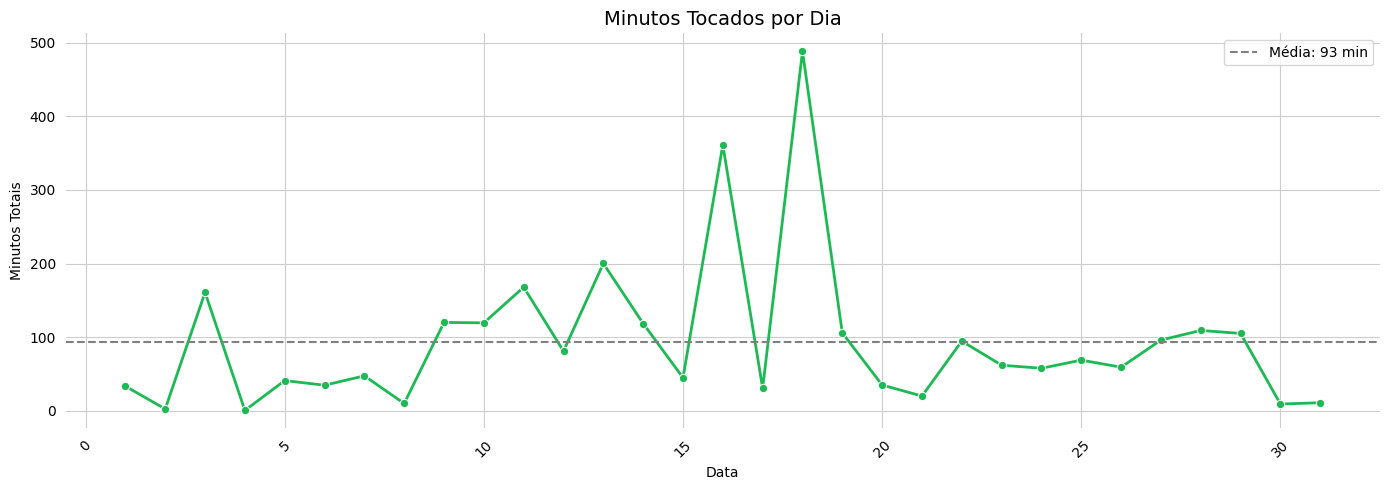

Gráfico 'daily_evolution.png' salvo.


In [10]:
# 2. Gráfico de Tempo Diário
plotar_grafico_diario(df)

In [11]:
# 3. Artistas Mais Ouvidos
top_artistas = calcular_artistas_mais_ouvidos(df, df_mes_anterior, top_n=5)

🎤  CÁPSULA SONORA: ARTISTAS MAIS OUVIDOS
Total de Artistas Diferentes: 154
Em comparação a 54 artistas no mês anterior (+185%)

🏆 Top 5 Artistas:
  1. Anitta — 1074.9 min (397 streams)
  2. Gilsons — 141.2 min (47 streams)
  3. Liniker — 109.5 min (28 streams)
  4. Coldplay — 105.1 min (26 streams)
  5. Dua Lipa — 54.8 min (17 streams)



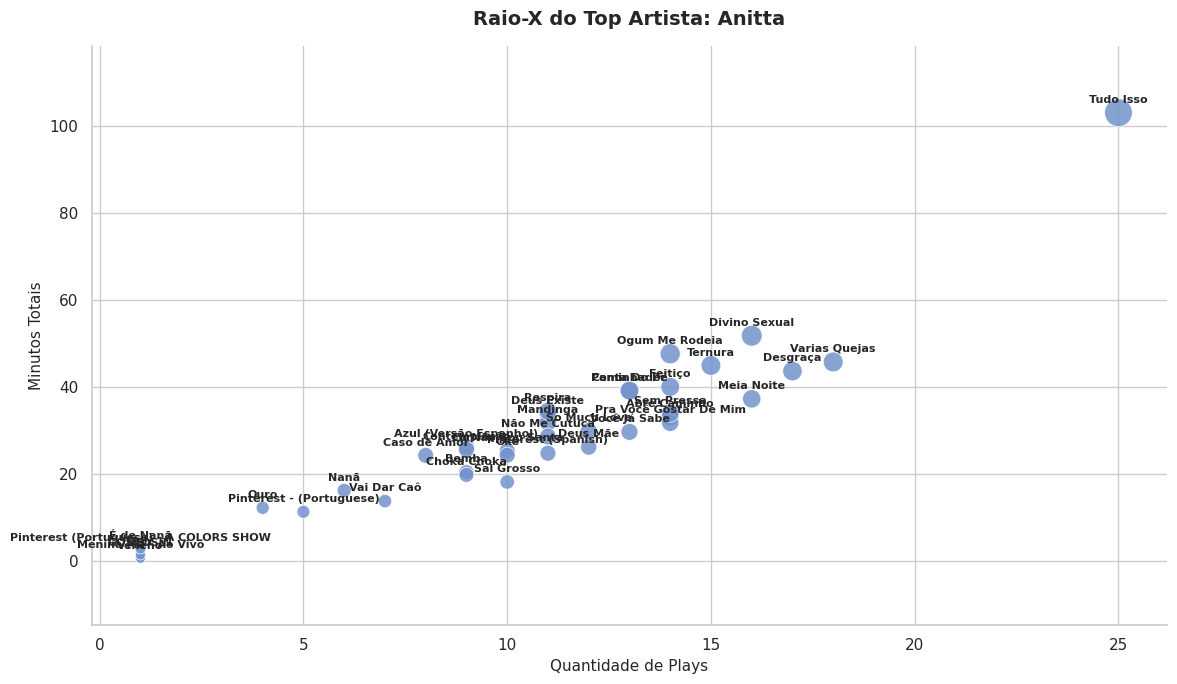

In [12]:
# Investigando como o top 1 artista acumulou minutos (muitos hits curtos ou álbuns inteiros?)
top_1_artista = top_artistas.iloc[0]['artista']

# Filtra apenas o artista top 1 e com reproduções >= 30s
df_raiox = df[(df['artista'] == top_1_artista) & (df['ms_tocados'] >= 30000)].copy()

raiox_faixas = (
    df_raiox.groupby('musica')
    .agg({'ms_tocados': 'sum', 'ts': 'count'})
    .reset_index()
)
raiox_faixas.columns = ['Faixa', 'Minutos Totais', 'Quantidade de Plays']

# Conversão de milissegundos para minutos
raiox_faixas['Minutos Totais'] = raiox_faixas['Minutos Totais'] / 60000

# Configuração do gráfico
sns.set_theme(style='whitegrid')
plt.figure(figsize=(12, 7))

ax = sns.scatterplot(
    data=raiox_faixas,
    x='Quantidade de Plays',
    y='Minutos Totais',
    size='Minutos Totais',
    sizes=(50, 400),
    color='#7293CB',
    alpha=0.85,
    legend=False,
)

# Adiciona os rótulos de texto de cada faixa acima dos pontos
for _, row in raiox_faixas.iterrows():
    ax.annotate(
        row['Faixa'],
        (row['Quantidade de Plays'], row['Minutos Totais']),
        textcoords='offset points',
        xytext=(0, 7),
        ha='center',
        fontsize=8,
        weight='semibold',
    )

# Título e formatações de eixo
plt.title(f'Raio-X do Top Artista: {top_1_artista}', fontsize=14, weight='bold', pad=15)
plt.xlabel('Quantidade de Plays', fontsize=11)
plt.ylabel('Minutos Totais', fontsize=11)

# Ajuste de margens para não cortar os textos superiores
ax.margins(y=0.15)
sns.despine()
plt.tight_layout()
plt.savefig("top_artist_distribution.png")
plt.show()

report_content_md.append("\n### Gráfico: Distribuição de músicas ouvidas da pessoa mais ouvida")
report_content_md.append(f"<img src='top_artist_distribution.png' alt='Como o top 1 artista acumulou minutos' style='width:600px; max-width:100%;'>")

In [13]:
# 4. Músicas Mais Ouvidas (Streams)
top_musicas = calcular_musicas_mais_ouvidas(df, df_mes_anterior, top_n=5)

🎵  CÁPSULA SONORA: MÚSICAS MAIS OUVIDAS
Total de Faixas Iniciadas: 1123
Total de Músicas Diferentes: 342
Em comparação a 112 músicas no mês anterior (+205%)

🔥 Top 5 Músicas Mais Tocadas:
  1. Tudo Isso - Anitta: 25 streams (103.1 min)
  2. POTE DE OURO - Liniker: 18 streams (70.3 min)
  3. Varias Quejas - Anitta: 18 streams (45.7 min)
  4. Desgraça - Anitta: 17 streams (43.6 min)
  5. Divino Sexual - Anitta: 16 streams (51.8 min)



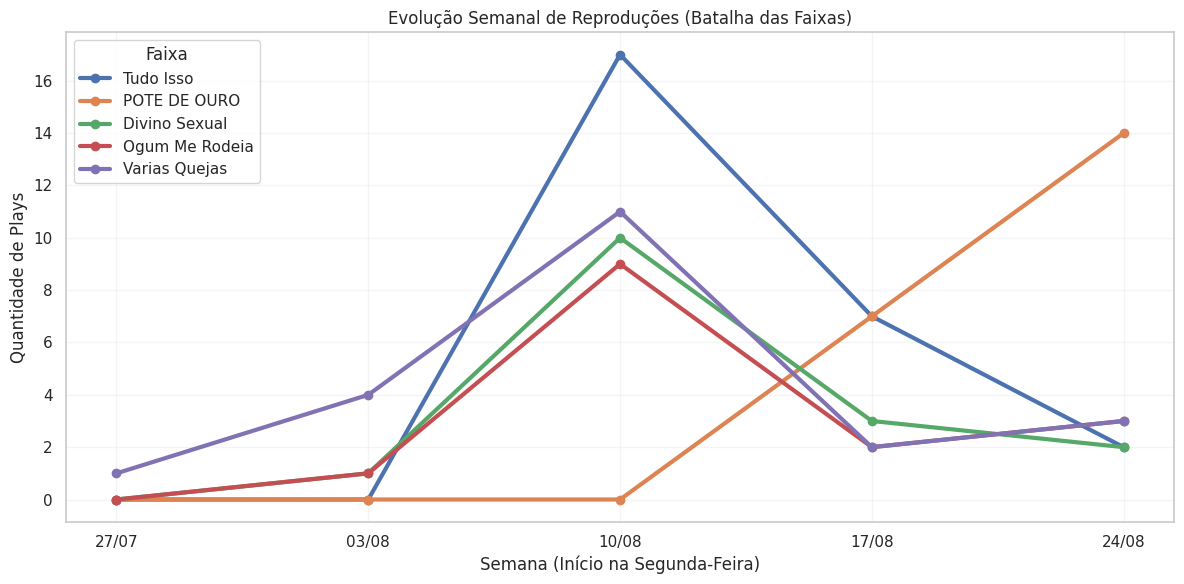

Gráfico 'weekly_track_evolution.png' salvo.


In [14]:
# Converte o timestamp para datetime caso ainda não seja
df['ts'] = pd.to_datetime(df['ts'])

# Identificar as top N músicas mais ouvidas
top_tracks_overall = (
    df[df['ms_tocados'] >= 30000]
    .groupby('musica')['minutos_tocados']
    .sum()
    .nlargest(5)
    .index.tolist()
)

# Filtrar o df para essas top N músicas
df_top_tracks = df[df['musica'].isin(top_tracks_overall)].copy()

# Encontra a segunda-feira correspondente de cada data mantendo tipo Timestamp
# (subtrai o dia da semana: segunda=0, terça=1, etc.)
df_top_tracks['inicio_semana'] = (
    df_top_tracks['ts'].dt.floor('D') - pd.to_timedelta(df_top_tracks['ts'].dt.weekday, unit='D')
)

# Agrupa por data real (ordenação cronológica garantida)
weekly_plays = df_top_tracks.groupby(['inicio_semana', 'musica']).size().unstack(fill_value=0)

# Assegurar que todas as faixas estejam presentes
for track in top_tracks_overall:
    if track not in weekly_plays.columns:
        weekly_plays[track] = 0

weekly_trends = weekly_plays[top_tracks_overall].sort_index()

# Converte o índice cronológico para string formatada apenas para exibição
weekly_trends.index = weekly_trends.index.strftime('%d/%m')

# Plotando
plt.figure(figsize=(12, 6))
for track in weekly_trends.columns:
    plt.plot(weekly_trends.index, weekly_trends[track], marker='o', linewidth=3, label=track)

plt.title('Evolução Semanal de Reproduções (Batalha das Faixas)')
plt.xlabel('Semana (Início na Segunda-Feira)')
plt.ylabel('Quantidade de Plays')
plt.legend(title='Faixa')
plt.grid(True, alpha=0.2)
plt.gca().yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("weekly_track_evolution.png")
plt.show()
print("Gráfico 'weekly_track_evolution.png' salvo.")

report_content_md.append("\n### Gráfico: Evolução Semanal de Reproduções das Músicas mais Ouvidas")
report_content_md.append(f"<img src='weekly_track_evolution.png' alt='Evolução Semanal de Reproduções' style='width:600px; max-width:100%;'>")

In [15]:
top_albuns = calcular_albuns_mais_ouvidos(df, df_mes_anterior, top_n=5)

💿  CÁPSULA SONORA: ÁLBUNS MAIS OUVIDOS
Total de Álbuns Diferentes: 242
Em comparação a 83 álbuns no mês anterior (+192%)

🏆 Top 5 Álbuns Mais Tocados:
  1. EQUILIBRIVM II - Anitta: 1018.8 min (371 streams)
  2. CAJU - Liniker: 104.9 min (26 streams)
  3. Várias Queixas - Gilsons: 53.5 min (18 streams)
  4. Sob Rock - John Mayer: 41.2 min (11 streams)
  5. EQUILIBRIVM - Anitta: 36.9 min (15 streams)



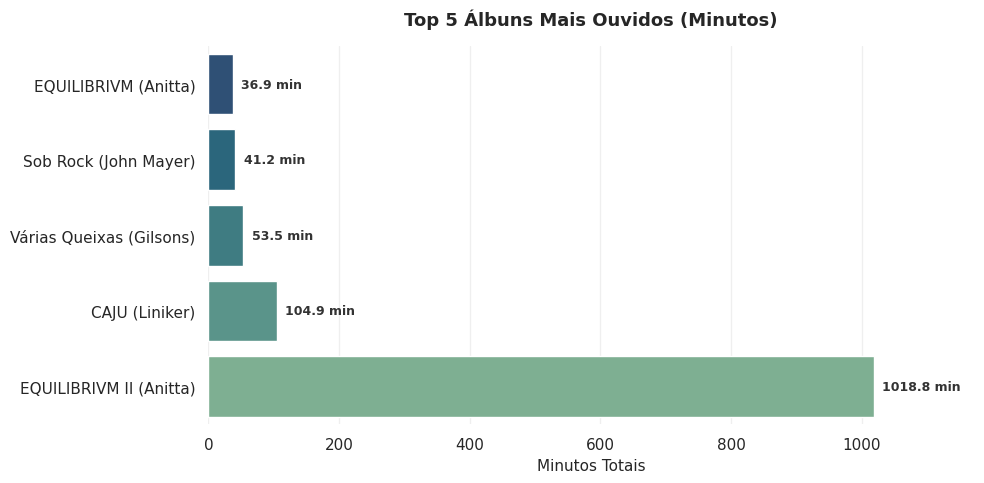

Gráfico 'top_albums.png' salvo.


In [16]:
plotar_top_albuns(top_albuns)

In [17]:
# 5. Semana com Mais Horas Alcançadas
identificar_semana_mais_musical(df)

📅  SEMANA MAIS MUSICAL
18 horas completas alcançadas!
Período: 10/08 até 16/08
Total: 1093.2 minutos ouvidos

📅  DIA MAIS MUSICAL
🔥 Dia em que você mais ouviu música: 18/08/2026 com 488 minutos tocados!



## 4. Visão Geral: Plataformas Utilizadas
Cálculo da distribuição de dispositivos.


📱 Distribuição percentual de dispositivos:
plataforma
android    88.5
windows    11.5
Name: proportion, dtype: float64


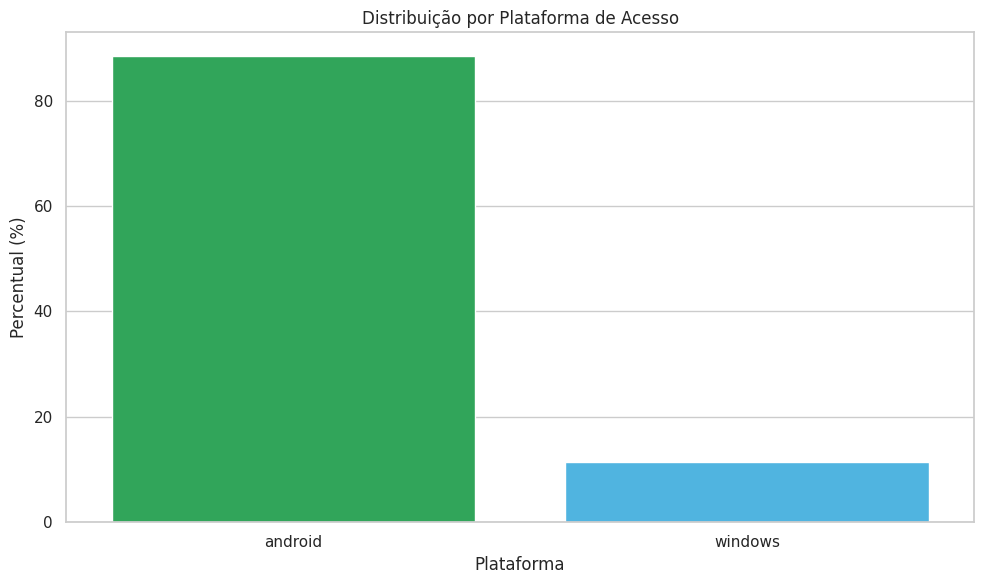

Gráfico 'platform_distribution.png' salvo.


In [18]:
# Distribuição por plataforma
dist_plataforma = df['plataforma'].value_counts(normalize=True) * 100
print("\n📱 Distribuição percentual de dispositivos:")
print(dist_plataforma.round(1))

# Gráfico de Dispositivos (Bar Chart)
plt.figure(figsize=(10, 6))
sns.barplot(x=dist_plataforma.index, y=dist_plataforma.values, palette=PALETA_SPOTIFY[:len(dist_plataforma.index)], hue=dist_plataforma.index, legend=False)
plt.title('Distribuição por Plataforma de Acesso')
plt.xlabel('Plataforma')
plt.ylabel('Percentual (%)')
plt.tight_layout()
plt.savefig("platform_distribution.png")
plt.show()
print("Gráfico 'platform_distribution.png' salvo.")

report_content_md.append("\n### Gráfico: Distribuição por Plataforma de Acesso")
report_content_md.append(f"<img src='platform_distribution.png' alt='Distribuição por Plataforma de Acesso' style='width:600px; max-width:100%;'>")

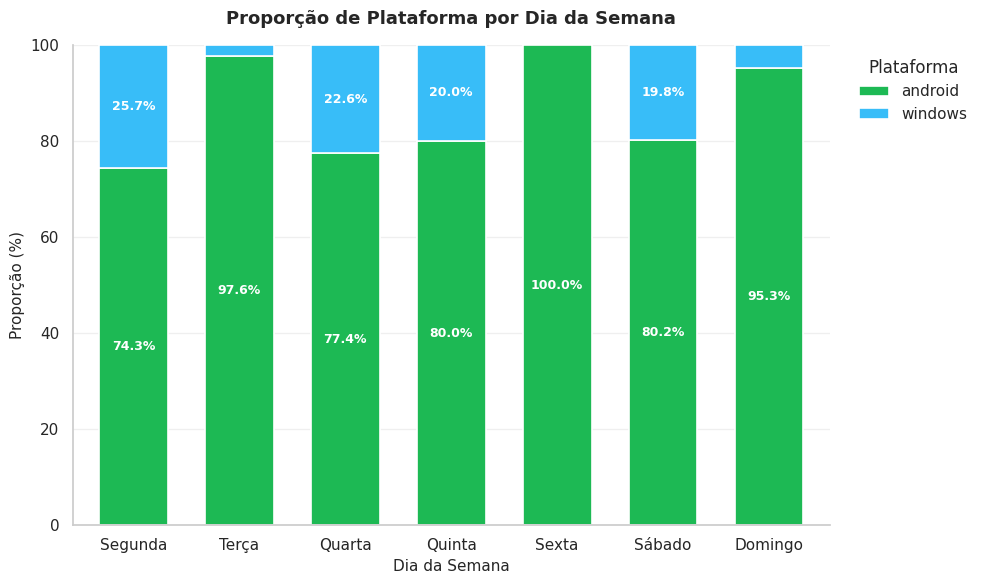

Gráfico 'platform_distribution_weekly.png' salvo.


In [19]:
# Converte o timestamp para datetime caso necessário
df['ts'] = pd.to_datetime(df['ts'])

# Cria a coluna com o nome do dia da semana em português ordenado
dias_ordem = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
mapa_dias = {
    0: 'Segunda',
    1: 'Terça',
    2: 'Quarta',
    3: 'Quinta',
    4: 'Sexta',
    5: 'Sábado',
    6: 'Domingo',
}
df['dia_semana'] = df['ts'].dt.weekday.map(mapa_dias)

# Calcula a tabela de contingência percentual (100% empilhado por dia)
prop_dia_plataforma = (
    pd.crosstab(df['dia_semana'], df['plataforma'], normalize='index')
    .reindex(dias_ordem)
    * 100
)

# Plotagem em barras empilhadas 100%
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
ax.set_facecolor('white')

cores = PALETA_SPOTIFY[: len(prop_dia_plataforma.columns)] if 'PALETA_SPOTIFY' in locals() else None

prop_dia_plataforma.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=cores,
    edgecolor='white',
    linewidth=1.2,
    width=0.65,
)

# Adiciona anotação de porcentagem dentro dos blocos (acima de 5%)
for p in ax.patches:
    h = p.get_height()
    if h >= 5:
        x = p.get_x() + p.get_width() / 2
        y = p.get_y() + h / 2
        ax.annotate(
            f'{h:.1f}%',
            (x, y),
            ha='center',
            va='center',
            color='white',
            weight='bold',
            fontsize=9,
        )

ax.set_title('Proporção de Plataforma por Dia da Semana', fontsize=13, weight='bold', pad=15)
ax.set_xlabel('Dia da Semana', fontsize=11)
ax.set_ylabel('Proporção (%)', fontsize=11)
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='-', alpha=0.3, color='#cccccc')
ax.legend(title='Plataforma', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.savefig("platform_distribution_weekly.png", dpi=300, facecolor='white')
plt.show()
print("Gráfico 'platform_distribution_weekly.png' salvo.")

report_content_md.append("\n### Gráfico: Proporção de Plataforma por Dia da Semana")
report_content_md.append(f"<img src='platform_distribution_weekly.png' alt='Proporção de Plataforma por Dia da Semana' style='width:600px; max-width:100%;'>")

## 5. Comportamento: Gatilhos, Puladas e Taxa de Rejeição (*Skip Rate*)
Identificação das razões de início e término das faixas, além do cálculo da taxa de descarte por artista.


### 5.1 Gatilhos de início e fim

In [20]:
print("--- Gatilhos de Início (reason_start %) ---")
motivos_inicio = (df['motivo_inicio'].value_counts(normalize=True) * 100).round(1)
print(motivos_inicio)

linhas_tabela = [
    "| Motivo | Percentual (%) |",
    "| :--- | :---: |"
]

for motivo, perc in motivos_inicio.items():
    linhas_tabela.append(f"| `{motivo}` | {perc:.1f}% |")

tabela_md = "\n".join(linhas_tabela)

report_content_md.append(f"\n### Gatilhos de Início (reason_start %)")
report_content_md.append(f"\n{tabela_md}")

--- Gatilhos de Início (reason_start %) ---
motivo_inicio
trackdone     73.2
fwdbtn        11.0
clickrow       6.7
backbtn        4.8
appload        3.5
playbtn        0.7
trackerror     0.1
Name: proportion, dtype: float64


In [21]:
print("\n--- Motivos de Término da Reprodução (reason_end %) ---")
motivos_fim = (df['motivo_fim'].value_counts(normalize=True) * 100).round(1)
print(motivos_fim)

for motivo, perc in motivos_fim.items():
    linhas_tabela.append(f"| `{motivo}` | {perc:.1f}% |")

tabela_md = "\n".join(linhas_tabela)

report_content_md.append("\n### Motivos de Término da Reprodução (reason_end %)")
report_content_md.append(f"\n{tabela_md}")


--- Motivos de Término da Reprodução (reason_end %) ---
motivo_fim
trackdone                       72.8
fwdbtn                          11.0
endplay                          5.2
backbtn                          4.8
logout                           4.0
unexpected-exit-while-paused     2.0
unexpected-exit                  0.3
Name: proportion, dtype: float64


### 5.2 Taxa de Rejeição (Skip Rate) por Artista

In [22]:
# Considera-se pulo voluntário quando o usuário aperta 'fwdbtn' ou skipped=True
df_temp = df.copy() # Create a copy to avoid SettingWithCopyWarning
df_temp['is_skip'] = (df_temp['pulou'] == True) | (df_temp['motivo_fim'] == 'fwdbtn')

skip_por_artista = df_temp.groupby('artista').agg(
    total_plays=('musica', 'count'),
    pulos=('is_skip', 'sum')
).reset_index()

# Filtro com mínimo de 20 execuções para relevância estatística
skip_por_artista = skip_por_artista[skip_por_artista['total_plays'] >= 20].copy()
skip_por_artista['skip_rate'] = (skip_por_artista['pulos'] / skip_por_artista['total_plays'] * 100).round(1)
top_skips = skip_por_artista.sort_values(by='skip_rate', ascending=False).head(10)

print("\n⏭️ Artistas com maior Taxa de Rejeição (Skip Rate):")
print(top_skips.to_string(index=False))

linhas_tabela = [
    "| Artista | Total Plays | Pulos | Skip Rate |",
    "| :--- | :---: | :---: | :---: |"
]

for row in top_skips.itertuples():
    linhas_tabela.append(f"| `{row.artista}` | `{row.total_plays}` | `{row.pulos}` | {row.skip_rate:.1f}% |")

report_content_md.append("\n### ⏭️ Artistas com Maior Taxa de Rejeição (Skip Rate)\n")
report_content_md.append("\n".join(linhas_tabela))


⏭️ Artistas com maior Taxa de Rejeição (Skip Rate):
 artista  total_plays  pulos  skip_rate
  Anitta          491    113       23.0
 Liniker           33      7       21.2
 Gilsons           57     11       19.3
Coldplay           27      1        3.7


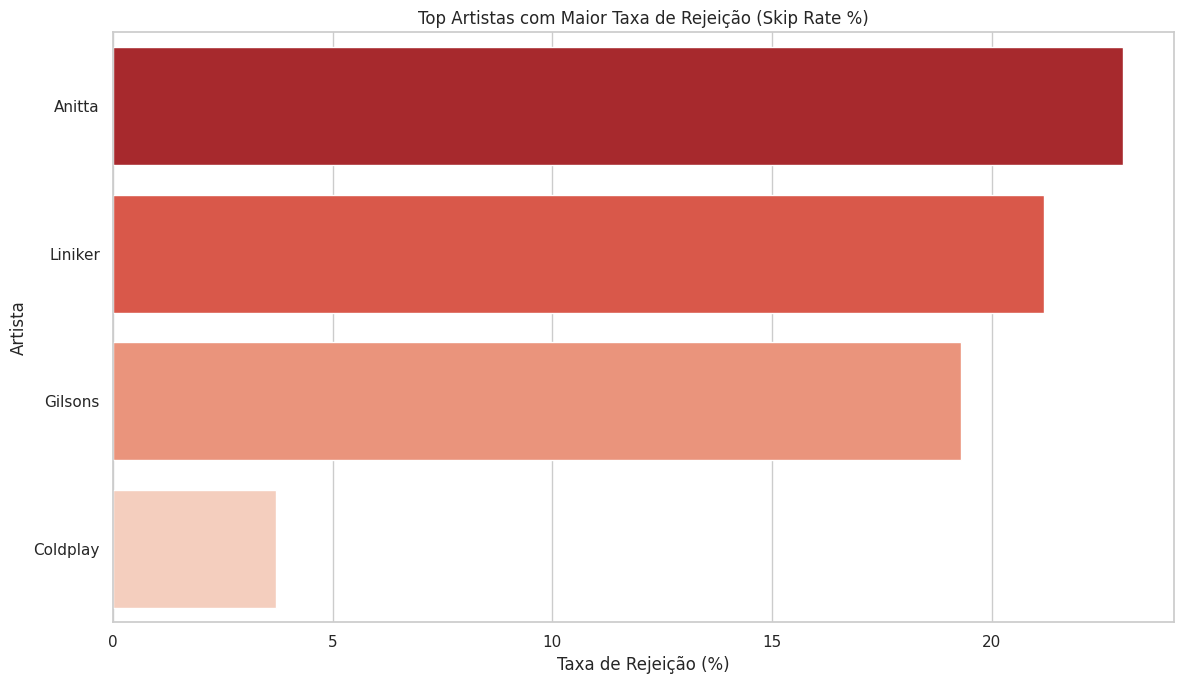

Gráfico 'skip_rate_artists.png' salvo.


In [23]:
# Gráfico de Barras: Skip Rate com Seaborn
plt.figure(figsize=(12, 7))
sns.barplot(x='skip_rate', y='artista', data=top_skips, palette='Reds_r', hue='artista', legend=False)
plt.title('Top Artistas com Maior Taxa de Rejeição (Skip Rate %)')
plt.xlabel('Taxa de Rejeição (%)')
plt.ylabel('Artista')
plt.tight_layout()
plt.savefig("skip_rate_artists.png")
plt.show()
print("Gráfico 'skip_rate_artists.png' salvo.")

report_content_md.append("\n### Gráfico: Top Artistas com Maior Taxa de Rejeição")
report_content_md.append(f"<img src='skip_rate_artists.png' alt='Top Artistas com Maior Taxa de Rejeição' style='width:600px; max-width:100%;'>")

### 5.3 Taxa de Rejeição por Música

In [24]:
# Identificando faixas com alta taxa de rejeição (botão 'next' / 'fwdbtn')

# O Spotify considera 'fwdbtn' quando você aperta o botão de avançar para a próxima música.
df['foi_pulada'] = df['motivo_fim'] == 'fwdbtn'

# Agrupando por música para ver o total de aparições e o total de pulos
analise_skips = df.groupby(['musica', 'artista']).agg(
    total_aparicoes=('musica', 'count'),
    vezes_pulada=('foi_pulada', 'sum')
).reset_index()

# Calculando a taxa de rejeição (Skip Rate)
analise_skips['taxa_rejeicao_%'] = (analise_skips['vezes_pulada'] / analise_skips['total_aparicoes']) * 100

# Filtrando para músicas que apareceram pelo menos 3 vezes no seu dia a dia
# (Isso evita que músicas tocadas 1 vez e puladas 1 vez fiquem no topo com 100% de rejeição)
musicas_enjoadas = analise_skips[analise_skips['total_aparicoes'] >= 3].sort_values(by='vezes_pulada', ascending=False)

print("⏭️ TOP MÚSICAS MAIS PULADAS (Potencialmente Enjoada):")
print(musicas_enjoadas[['musica', 'artista', 'vezes_pulada', 'total_aparicoes', 'taxa_rejeicao_%']].head(10).round(1).to_string(index=False))

report_content_md.append(f"\n⏭️ TOP MÚSICAS MAIS PULADAS (Potencialmente Enjoada):")
report_content_md.append(f"\n{musicas_enjoadas[['musica', 'artista', 'vezes_pulada', 'total_aparicoes', 'taxa_rejeicao_%']].head(10).round(1).to_string(index=False)}")

⏭️ TOP MÚSICAS MAIS PULADAS (Potencialmente Enjoada):
                musica artista  vezes_pulada  total_aparicoes  taxa_rejeicao_%
                  Ouro  Anitta            10               13             76.9
           Vai Dar Caô  Anitta             5               11             45.5
          Contemplação  Anitta             5               16             31.2
              Deus Mãe  Anitta             4               15             26.7
      Eu Não Sou Santa  Anitta             3               13             23.1
           Deus Existe  Anitta             3               13             23.1
                   Okê  Anitta             3               13             23.1
           Choka Choka  Anitta             3               12             25.0
Azul (Versão Espanhol)  Anitta             3               11             27.3
                  Nanã  Anitta             3                8             37.5


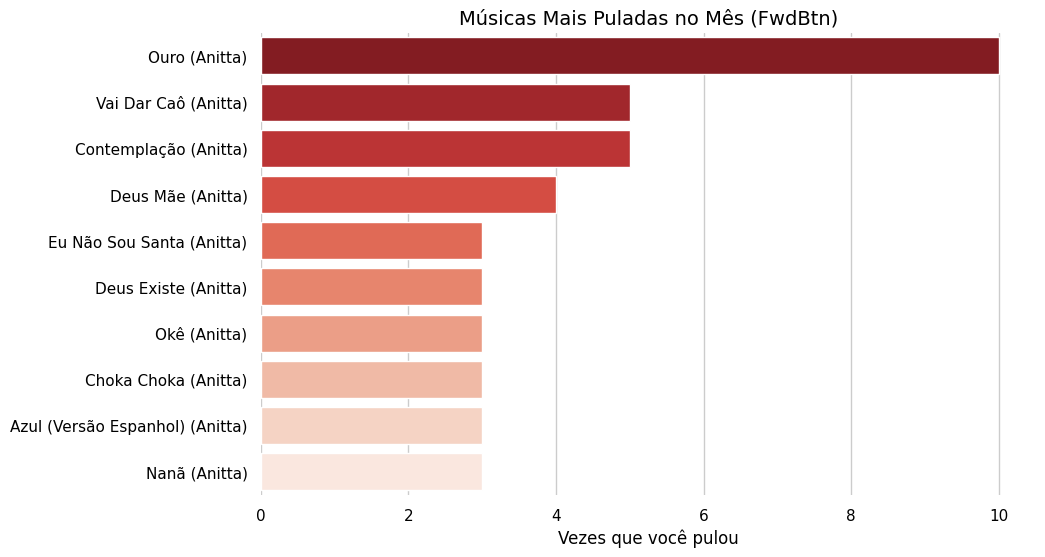

In [25]:
# Gráfico: Top Músicas Puladas
plt.figure(figsize=(10, 6))
top_puladas_grafico = musicas_enjoadas.head(10).copy()
top_puladas_grafico['label'] = top_puladas_grafico['musica'] + ' (' + top_puladas_grafico['artista'] + ')'

# Usando uma paleta avermelhada para indicar "rejeição"
sns.barplot(data=top_puladas_grafico, x='vezes_pulada', y='label',  hue='label',palette='Reds_r')
plt.title('Músicas Mais Puladas no Mês (FwdBtn)', fontsize=14, color='black')
plt.xlabel('Vezes que você pulou', color='black')
plt.ylabel('', color='black')
plt.xticks(color='black')
plt.yticks(color='black')
sns.despine(left=True, bottom=True)
plt.savefig("skip_musics.png")
plt.show()

report_content_md.append("\n### Gráfico: Músicas Mais Puladas no Mês")
report_content_md.append(f"<img src='skip_musics.png' alt='Músicas Mais Puladas no Mês' style='width:600px; max-width:100%;'>")

## 6. Análise Temporal e Rotina (Cronotipo Musical)
Distribuição do consumo musical por hora do dia, dias da semana e detecção de maratonas ininterruptas.

### 6.1 Distribuição por Período do Dia

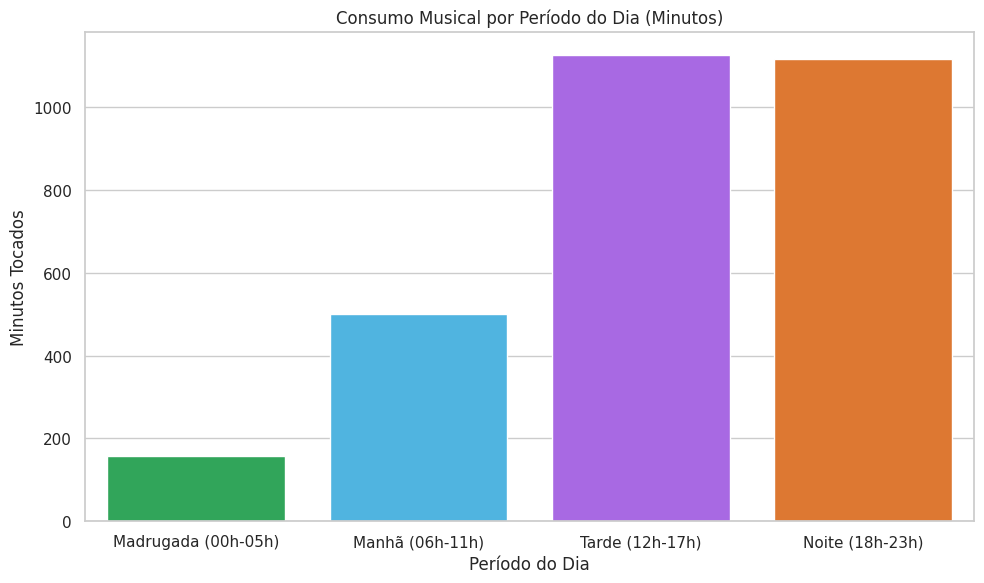

Gráfico 'time_of_day_distribution.png' salvo.


In [26]:
bins = [-1, 5, 11, 17, 23]
labels = ['Madrugada (00h-05h)', 'Manhã (06h-11h)', 'Tarde (12h-17h)', 'Noite (18h-23h)']

# Criar uma cópia explícita para evitar SettingWithCopyWarning
df_plot = df.copy()
df_plot['periodo_dia'] = pd.cut(df_plot['hora'], bins=bins, labels=labels)

tempo_periodo = df_plot.groupby('periodo_dia', observed=False)['minutos_tocados'].sum().reset_index()

# Gráfico de Barras: Consumo Musical por Período do Dia com Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='periodo_dia', y='minutos_tocados', data=tempo_periodo, palette=PALETA_SPOTIFY[:len(labels)], hue='periodo_dia', legend=False)
plt.title('Consumo Musical por Período do Dia (Minutos)')
plt.xlabel('Período do Dia')
plt.ylabel('Minutos Tocados')
plt.tight_layout()
plt.savefig("time_of_day_distribution.png")
plt.show()
print("Gráfico 'time_of_day_distribution.png' salvo.")

report_content_md.append("\n### Gráfico: Consumo Musical por Período do Dia (Minutos)")
report_content_md.append(f"<img src='time_of_day_distribution.png' alt='Consumo Musical por Período do Dia (Minutos)' style='width:600px; max-width:100%;'>")

### 6.2 Sessões Ininterruptas (Detecção de Maratonas de Foco / Treino)

In [27]:
df_sorted = df.sort_values('ts').copy()
df_sorted['inicio_faixa'] = df_sorted['ts'] - pd.to_timedelta(df_sorted['ms_tocados'], unit='ms')
df_sorted['intervalo_anterior'] = df_sorted['inicio_faixa'] - df_sorted['ts'].shift(1)

# Nova sessão se o intervalo for maior que 10 minutos
df_sorted['sessao_id'] = (df_sorted['intervalo_anterior'] > pd.Timedelta(minutes=10)).cumsum()

maratonas = df_sorted.groupby('sessao_id').agg(
    inicio=('inicio_faixa', 'min'),
    fim=('ts', 'max'),
    minutos_totais=('minutos_tocados', 'sum'),
    qtd_musicas=('musica', 'count')
).reset_index()

maratonas['horas_totais'] = (maratonas['minutos_totais'] / 60.0).round(1)
top_maratonas = maratonas.sort_values(by='minutos_totais', ascending=False).head(5)

print("\n🎧 Top 5 Maiores Maratonas de Escuta Ininterrupta:")
print(top_maratonas[['inicio', 'fim', 'horas_totais', 'qtd_musicas']].to_string(index=False))

# Construção da tabela nativa em Markdown para o relatório
tabela_maratonas = [
    "| # | Início | Fim | Duração | Faixas Ouvidas |",
    "| :-: | :--- | :--- | :-: | :-: |"
]

for idx, (_, row) in enumerate(top_maratonas.iterrows(), 1):
    inicio_fmt = row['inicio'].strftime('%d/%m/%Y %H:%M')
    fim_fmt = row['fim'].strftime('%d/%m/%Y %H:%M')
    duracao_fmt = f"{row['horas_totais']:.1f}h ({int(round(row['minutos_totais']))} min)"

    tabela_maratonas.append(
        f"| {idx} | {inicio_fmt} | {fim_fmt} | {duracao_fmt} | {row['qtd_musicas']} |"
    )

report_content_md.append("\n### 🎧 Top 5 Maiores Maratonas de Escuta Ininterrupta\n")
report_content_md.append("\n".join(tabela_maratonas))


🎧 Top 5 Maiores Maratonas de Escuta Ininterrupta:
                          inicio                       fim  horas_totais  qtd_musicas
2026-08-18 18:11:01.101000-03:00 2026-08-18 22:40:45-03:00           4.4           82
2026-08-16 10:11:00.924000-03:00 2026-08-16 13:11:12-03:00           2.9           61
2026-08-16 06:39:14.180000-03:00 2026-08-16 09:32:03-03:00           2.6           48
2026-08-18 13:22:37.684000-03:00 2026-08-18 15:46:19-03:00           2.4           46
2026-08-12 23:19:19.940000-03:00 2026-08-13 01:02:00-03:00           1.7           42


### 6.3 Análise Semanal: Distribuição por Dia da Semana

📊 Tempo Total de Escuta por Dia da Semana:
   dia_semana  minutos_tocados
Segunda-feira       379.554333
  Terça-feira       725.639133
 Quarta-feira       287.080467
 Quinta-feira       366.025900
  Sexta-feira       295.233767
       Sábado       287.945000
      Domingo       554.842483


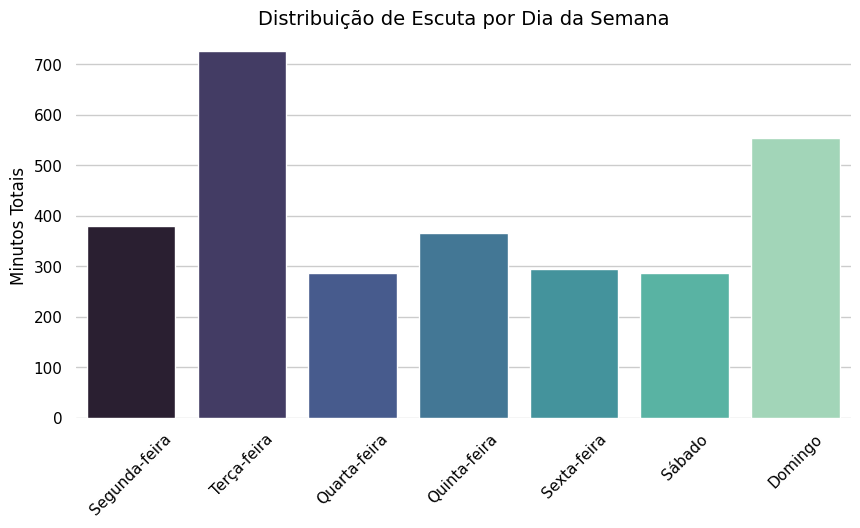

In [28]:
# 1. Extração e Tradução dos Dias da Semana
# O Pandas retorna 0 para Segunda-feira e 6 para Domingo
df['dia_semana_num'] = df['ts'].dt.dayofweek
dias_traducao = {
    0: 'Segunda-feira',
    1: 'Terça-feira',
    2: 'Quarta-feira',
    3: 'Quinta-feira',
    4: 'Sexta-feira',
    5: 'Sábado',
    6: 'Domingo'
}
df['dia_semana'] = df['dia_semana_num'].map(dias_traducao)

# 2. Agrupamento de Dados
# Agrupa pelos números para manter a ordem correta, e depois aplica os nomes
tempo_por_dia = df.groupby(['dia_semana_num', 'dia_semana'])['minutos_tocados'].sum().reset_index()

print("📊 Tempo Total de Escuta por Dia da Semana:")
print(tempo_por_dia[['dia_semana', 'minutos_tocados']].to_string(index=False))

# 3. Visualização Gráfica
plt.figure(figsize=(10, 5))
sns.barplot(
    data=tempo_por_dia,
    x='dia_semana',
    hue='dia_semana',
    y='minutos_tocados',
    palette='mako',
    legend=False
)

plt.title('Distribuição de Escuta por Dia da Semana', fontsize=14, color='black')
plt.xlabel('', color='black')
plt.ylabel('Minutos Totais', color='black')
plt.xticks(rotation=45, color='black')
plt.yticks(color='black')
sns.despine(left=True, bottom=True)
plt.savefig("music_listening_week.png")
plt.show()

report_content_md.append("\n### Gráfico: Distribuição de Escuta por Dia da Semana")
report_content_md.append(f"<img src='music_listening_week.png' alt='' style='width:600px; max-width:100%;'>")

## 7. Novas curtidas

In [29]:
# 1. Identificar as músicas curtidas no mês
# Carregar os eventos de "like"
df_curtidas = pd.read_json('drive/MyDrive/spotify/Spotify Technical Log Information/AddedToCollection.json')

# Filtrar para o mês desejado e isolar a ação de curtir
df_curtidas['data_curtida'] = pd.to_datetime(df_curtidas['timestamp_utc'])
df_mes = df_curtidas[(df_curtidas['data_curtida'].dt.year == ANO_ANALISADO) &
                     (df_curtidas['data_curtida'].dt.month == MES_ANALISADO)]
df_likes = df_mes[df_mes['message_set'] == 'collection']

# Carregar os nomes reais das faixas da biblioteca
with open('drive/MyDrive/spotify/Spotify Account Data/YourLibrary.json', 'r', encoding='utf-8') as f:
    lib_data = json.load(f)
df_nomes = pd.DataFrame(lib_data['tracks']).drop_duplicates(subset=['uri'])

# Cruzar os códigos URI para obter o nome da música e do artista
likes_com_nome = pd.merge(df_likes, df_nomes, left_on='message_item_uri', right_on='uri', how='inner')

# Ordena cronologicamente primeiro
likes_com_nome = likes_com_nome.sort_values('data_curtida', ascending=False)

# Trunca para o minuto: elimina duplicatas de requests duplos na mesma janela
likes_com_nome['minuto_curtida'] = likes_com_nome['data_curtida'].dt.floor('min')
likes_com_nome = likes_com_nome.drop_duplicates(subset=['message_item_uri', 'minuto_curtida'])

print("Músicas curtidas no mês:")
print(f"\nQuantidade: {len(likes_com_nome)}")
display(likes_com_nome[['data_curtida', 'track', 'artist', 'album']])

# Montando a tabela em Markdown de forma nativa
tabela_likes = [
    "| Data / Hora | Música | Artista | Álbum |",
    "| :--- | :--- | :--- |:--- |"
]

for _, row in likes_com_nome.iterrows():
    data_formatada = row['data_curtida'].strftime('%d/%m/%Y %H:%M')
    tabela_likes.append(f"| {data_formatada} | {row['track']} | {row['artist']} | {row['album']} |")

report_content_md.append("\n### 🎧 Músicas Curtidas no Mês\n")
report_content_md.append(f"**Total de músicas adicionadas:** {len(likes_com_nome)}\n")
report_content_md.append("\n".join(tabela_likes))

Músicas curtidas no mês:

Quantidade: 44


,data_curtida,track,artist,album
70,2026-08-16 09:18:45.577000+00:00,Assim Caminha a Humanidade,Lulu Santos,Assim Caminha A Humanidade
21,2026-08-16 09:18:19.220000+00:00,Somewhere Only We Know,Lily Allen,Somewhere Only We Know
84,2026-08-16 09:16:20.381000+00:00,Fracasso - Ao Vivo,Pitty,A Trupe Delirante No Circo Voador Ao Vivo
32,2026-08-16 09:13:37.051000+00:00,Ela Disse Adeus,Os Paralamas Do Sucesso,Arquivo II 1991 - 2000
25,2026-08-16 09:10:30.252000+00:00,Um Minuto Para O Fim Do Mundo,CPM 22,CPM22 - 20 Anos
47,2026-08-16 08:58:25.665000+00:00,Como Eu Quero - Live,Kid Abelha,Acústico
15,2026-08-16 08:58:18.416000+00:00,Dancing Queen - From 'Mamma Mia!' Original Mot...,Meryl Streep,Mamma Mia! The Movie Soundtrack
18,2026-08-16 08:58:02.908000+00:00,Escape (The Pina Colada Song),Rupert Holmes,'70s Pop #1's
0,2026-08-16 08:57:52.985000+00:00,Eu Quero Sempre Mais - Ao Vivo em São Paulo,Ira!,Ira! Folk
55,2026-08-16 08:57:47.271000+00:00,Every Breath You Take,The Police,Stranger Things (Soundtrack from the Netflix O...


In [30]:
# Mesclar os logs com os nomes e artistas reais
df_completo = pd.merge(df_likes, df_nomes, left_on='message_item_uri', right_on='uri', how='inner')

# 1. Artistas mais curtidos
top_artistas_curtidos = df_completo['artist'].value_counts().head(5)

print("--- SEUS ARTISTAS MAIS CURTIDOS ---")
print(top_artistas_curtidos)

tabela_artistas = [
    "| Artista | Músicas Curtidas |",
    "| :--- | :---: |"
]
for artista, qtd in top_artistas_curtidos.items():
    tabela_artistas.append(f"| {artista} | {qtd} |")

report_content_md.append("\n### ❤️ Artistas Mais Curtidos\n")
report_content_md.append("\n".join(tabela_artistas))


# 2. Dias de maior organização de biblioteca
# Mapeamento para português e ordenação por frequência
mapa_dias = {
    'Monday': 'Segunda-feira',
    'Tuesday': 'Terça-feira',
    'Wednesday': 'Quarta-feira',
    'Thursday': 'Quinta-feira',
    'Friday': 'Sexta-feira',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}
df_completo['dia_semana'] = df_completo['data_curtida'].dt.day_name().map(mapa_dias)
curtidas_por_dia = df_completo['dia_semana'].value_counts()

print("\n--- DIAS DE MAIOR ORGANIZAÇÃO DE BIBLIOTECA ---")
print(curtidas_por_dia)

tabela_dias = [
    "| Dia da Semana | Músicas Salvas |",
    "| :--- | :---: |"
]
for dia, qtd in curtidas_por_dia.items():
    tabela_dias.append(f"| {dia} | {qtd} |")

report_content_md.append("\n### 📅 Dias de Maior Organização de Biblioteca\n")
report_content_md.append("\n".join(tabela_dias))

--- SEUS ARTISTAS MAIS CURTIDOS ---
artist
Anitta               36
Alexandre Desplat     8
Kid Abelha            4
Meryl Streep          4
Cher                  2
Name: count, dtype: int64

--- DIAS DE MAIOR ORGANIZAÇÃO DE BIBLIOTECA ---
dia_semana
Domingo          50
Terça-feira      16
Segunda-feira    14
Quinta-feira      6
Quarta-feira      1
Name: count, dtype: int64


## 7. Análise de Sequências e Repetições em Loop (*No Repeat*)
Mapeia episódios de hiperfoco onde a mesma faixa foi tocada repetidamente em sequência.

### 7.1 Músicas mais repetidas na sequência

In [31]:
# Ordena o DataFrame cronologicamente para garantir que a sequência temporal esteja correta
df_seq = df.sort_values('ts').copy()

# Cria um identificador único para cada vez que a faixa muda
df_seq['mudanca_faixa'] = (df_seq['musica'] != df_seq['musica'].shift()).cumsum()

# Agrupa por esse identificador, contando quantas vezes tocou em sequência
repeticoes = df_seq.groupby(['mudanca_faixa', 'musica', 'artista']).agg(
    vezes_seguidas=('musica', 'count'),
    primeira_vez_tocada=('ts', 'min')
).reset_index()

# Filtra apenas as que tocaram mais de uma vez seguida e ordena
repeticoes = repeticoes[repeticoes['vezes_seguidas'] > 1].sort_values(by='vezes_seguidas', ascending=False)

# Pega o top 10 maiores repetições consecutivas
top_repeticoes = repeticoes.head(10).copy()

# Prepara os dados tabulados
top_repeticoes['Data / Hora'] = top_repeticoes['primeira_vez_tocada'].dt.strftime('%d/%m/%Y às %H:%M')
tabela_repeat = top_repeticoes[['musica', 'artista', 'vezes_seguidas', 'Data / Hora']].rename(
    columns={
        'musica': 'Música',
        'artista': 'Artista',
        'vezes_seguidas': 'Vezes Seguidas'
    }
)

# Saída no relatório Markdown (Opção 1: to_markdown - requer pip install tabulate)
report_content_md.append("\n### 🏆 Top Vezes no Repeat (Músicas Tocadas em Sequência)\n")

linhas_md = ["| Música | Artista | Vezes Seguidas | Início da Sessão |", "| :--- | :--- | :---: | :---: |"]
for _, row in tabela_repeat.iterrows():
     linhas_md.append(f"| {row['Música']} | {row['Artista']} | {row['Vezes Seguidas']}x | {row['Data / Hora']} |")
report_content_md.append("\n".join(linhas_md))

print("🏆 Top vezes em que você colocou a música no Repeat (tocadas em sequência):")
for _, row in top_repeticoes.iterrows():
    print(f"- {row['vezes_seguidas']}x seguidas: '{row['musica']}' ({row['artista']}) | Começou dia {row['Data / Hora']}")

🏆 Top vezes em que você colocou a música no Repeat (tocadas em sequência):
- 3x seguidas: 'Caso de Amor' (Anitta) | Começou dia 21/08/2026 às 11:23
- 2x seguidas: 'New Light' (John Mayer) | Começou dia 05/08/2026 às 15:09
- 2x seguidas: 'Lose Control' (Teddy Swims) | Começou dia 06/08/2026 às 13:20
- 2x seguidas: 'Algum Ritmo' (Gilsons) | Começou dia 06/08/2026 às 17:59
- 2x seguidas: 'River Waltz - From "The Painted Veil" Original Soundtrack' (Alexandre Desplat) | Começou dia 03/08/2026 às 23:11
- 2x seguidas: 'Dai Dai' (Shakira) | Começou dia 07/08/2026 às 20:08
- 2x seguidas: 'Sign of the Times' (Harry Styles) | Começou dia 07/08/2026 às 21:06
- 2x seguidas: 'Varias Quejas' (Anitta) | Começou dia 09/08/2026 às 11:14
- 2x seguidas: 'Dance The Night - From Barbie The Album' (Dua Lipa) | Começou dia 09/08/2026 às 10:02
- 2x seguidas: 'Varias Quejas' (Anitta) | Começou dia 10/08/2026 às 18:53


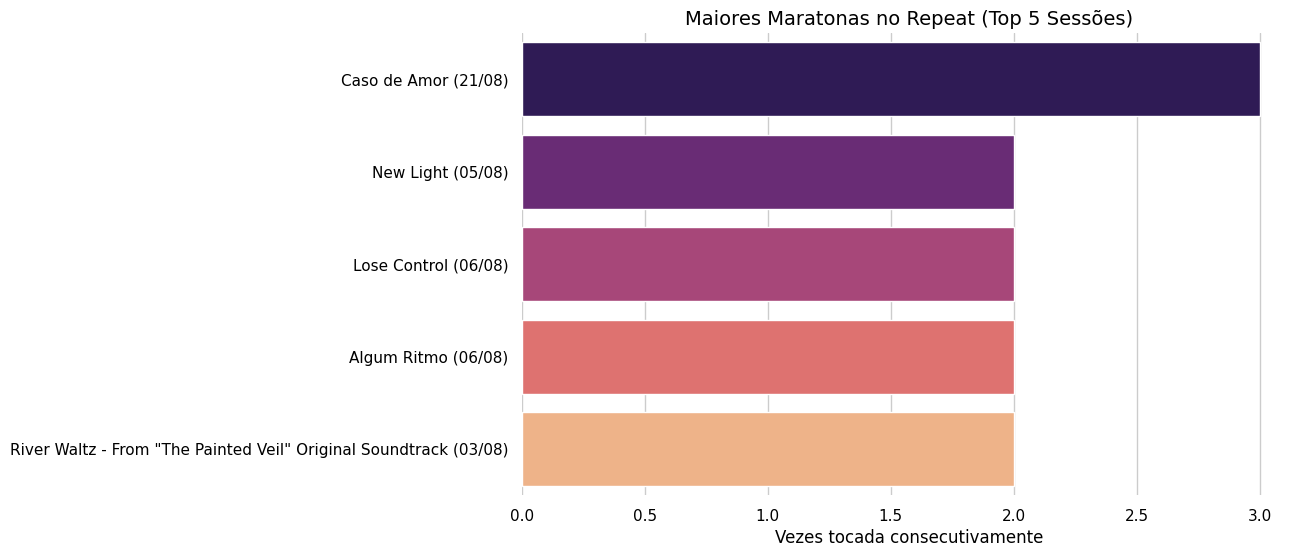

In [32]:
# Gráfico: Top Músicas no Repeat
plt.figure(figsize=(10, 6))

top_repeticoes = top_repeticoes.copy()

# Criando um label descritivo combinando faixa e número para não conflitar caso a mesma música apareça 2x no ranking
top_repeticoes['label_grafico'] = top_repeticoes['musica'] + " (" + top_repeticoes['primeira_vez_tocada'].dt.strftime('%d/%m') + ")"

sns.barplot(
    data=top_repeticoes.head(5),
    x='vezes_seguidas',
    y='label_grafico',
    hue='label_grafico',
    palette='magma',
    legend=False,
)

plt.title('Maiores Maratonas no Repeat (Top 5 Sessões)', fontsize=14, color='black')
plt.xlabel('Vezes tocada consecutivamente', color='black')
plt.ylabel('', color='black')
plt.xticks(color='black')
plt.yticks(color='black')
sns.despine(left=True, bottom=True)
plt.savefig("music_repeat.png")
plt.show()

report_content_md.append("\n### Gráfico: Maiores Maratonas no Repeat (Top 5 Sessões)")
report_content_md.append(f"<img src='music_repeat.png' alt='' style='width:600px; max-width:100%;'>")

### 7.2 Artistas mais ouvidos por dias consecutivos

In [33]:
# Mapeando os dias consecutivos em que o 'artista' tocou.
df['data'] = df['ts'].dt.date
dias_por_artista = df.groupby(['artista', 'data']).size().reset_index()
dias_por_artista['data'] = pd.to_datetime(dias_por_artista['data'])
dias_por_artista = dias_por_artista.sort_values(['artista', 'data'])

# Lógica vetorial para contar sequências ininterruptas de dias
dias_por_artista['diff_dias'] = dias_por_artista.groupby('artista')['data'].diff().dt.days
dias_por_artista['streak_id'] = (dias_por_artista['diff_dias'] != 1).cumsum()

streaks = dias_por_artista.groupby(['artista', 'streak_id']).size().reset_index(name='dias_consecutivos')
top_streaks = streaks.sort_values('dias_consecutivos', ascending=False).drop_duplicates('artista')

df_top10 = top_streaks[['artista', 'dias_consecutivos']].head(10).rename(
    columns={'artista': 'Artista', 'dias_consecutivos': 'Dias Consecutivos'}
)

print("\n### Artistas Mais Ouvidos por Dias Consecutivos\n")
display(df_top10)

# Adiciona o título e a tabela formatada em Markdown
report_content_md.append("\n### Artistas Mais Ouvidos por Dias Consecutivos\n")

linhas_tabela = ["| Artista | Dias Consecutivos |", "| :--- | :---: |"]
for _, row in df_top10.iterrows():
     linhas_tabela.append(f"| {row['Artista']} | {row['Dias Consecutivos']} |")
report_content_md.append("\n".join(linhas_tabela))


### Artistas Mais Ouvidos por Dias Consecutivos



,Artista,Dias Consecutivos
14,Anitta,8
187,Liniker,6
115,Gilsons,5
128,Harry Styles,4
295,Skank,3
54,Chappell Roan,3
285,Sandy e Junior,3
65,Coldplay,3
334,Zara Larsson,3
274,Rubel,3


### 7.3 Índice de Exploração

In [34]:
print("--- ÍNDICE DE EXPLORAÇÃO VS. NOSTALGIA ---")
# Cruzamos o volume total de plays com os nomes únicos das faixas ('master_metadata_track_name').
total_plays = len(df)
musicas_unicas = df['musica'].nunique()
indice_exploracao = (musicas_unicas / total_plays) * 100

print(f"Total de Plays: {total_plays}")
print(f"Músicas Únicas: {musicas_unicas}")
print(f"Índice de Exploração: {indice_exploracao:.1f}% (Quanto mais próximo de 100%, menos repetição)")

report_content_md.append("\n### ÍNDICE DE EXPLORAÇÃO VS. NOSTALGIA")
report_content_md.append(f"\nTotal de Plays: {total_plays}")
report_content_md.append(f"\nMúsicas Únicas: {musicas_unicas}")
report_content_md.append(f"\nÍndice de Exploração: {indice_exploracao:.1f}% (Quanto mais próximo de 100%, menos repetição)")

--- ÍNDICE DE EXPLORAÇÃO VS. NOSTALGIA ---
Total de Plays: 1123
Músicas Únicas: 342
Índice de Exploração: 30.5% (Quanto mais próximo de 100%, menos repetição)


## 10. Relatório Completo das Análises

In [35]:
# 1. Converte o Markdown ativando a extensão de tabelas
html_formatted_report_content = markdown.markdown(
    '\n'.join(report_content_md),
    extensions=['tables', 'fenced_code']
)

# 2. Exibe no notebook
display(Markdown('\n'.join(report_content_md)))

# 3. Salva com CSS específico para tabelas
html_content = f"""
<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>Relatório de Análise Spotify</title>
<style>
  body {{
    font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Helvetica, Arial, sans-serif;
    margin: 2em auto;
    max-width: 1000px;
    line-height: 1.6;
    color: #333;
    background-color: #f9f9f9;
    padding: 0 1.5em;
  }}
  h1, h2, h3, h4, h5, h6 {{
    color: #1DB954;
    margin-top: 1.5em;
    margin-bottom: 0.6em;
    line-height: 1.2;
  }}
  h1 {{ font-size: 2.2em; border-bottom: 2px solid #1DB954; padding-bottom: 0.3em; }}
  h2 {{ font-size: 1.6em; margin-top: 2em; }}
  h3 {{ font-size: 1.25em; }}
  p {{ margin-bottom: 1em; }}
  ul, ol {{ margin-bottom: 1em; padding-left: 25px; }}
  li {{ margin-bottom: 0.4em; }}
  img {{
    max-width: 100%;
    height: auto;
    display: block;
    margin: 1.5em auto;
    border-radius: 8px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
  }}

  /* ESTILIZAÇÃO DAS TABELAS */
  table {{
    width: 100%;
    border-collapse: collapse;
    margin: 1.5em 0;
    background-color: #ffffff;
    box-shadow: 0 2px 6px rgba(0,0,0,0.04);
    border-radius: 8px;
    overflow: hidden;
  }}
  th, td {{
    padding: 10px 14px;
    border-bottom: 1px solid #e5e5e5;
    text-align: left;
    font-size: 0.95em;
  }}
  th {{
    background-color: #f1f3f5;
    color: #212529;
    font-weight: 600;
    text-transform: uppercase;
    font-size: 0.82em;
    letter-spacing: 0.5px;
  }}
  tr:nth-child(even) {{
    background-color: #fafbfc;
  }}
  tr:hover {{
    background-color: #f1f7f3;
  }}

  /* CÓDIGOS E BLOCKS */
  pre, code {{
    background-color: #f4f4f4;
    border-radius: 4px;
    font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, Courier, monospace;
    color: #2c3e50;
    font-size: 0.9em;
  }}
  pre {{
    padding: 1em;
    overflow-x: auto;
    white-space: pre-wrap;
    word-wrap: break-word;
    margin-bottom: 1em;
    border: 1px solid #e9ecef;
  }}
  code {{ padding: 0.2em 0.4em; }}
  hr {{ border: 0; height: 1px; background: #e0e0e0; margin: 2em 0; }}
</style>
</head>
<body>
{html_formatted_report_content}
</body>
</html>
"""

with open(f"spotify_report_mes_{MES_ANALISADO}_{ANO_ANALISADO}.html", "w", encoding="utf-8") as f:
    f.write(html_content)

print(f"✅ Relatório HTML salvo com tabelas estruturadas.")

# Relatório de Análise Spotify - Mês 8/2026

--- 

## ⏱️  CÁPSULA SONORA: TEMPO OUVIDO

Total Ouvido: 2.896 minutos (2d 0h 16min)

Média Diária: 93 min/dia

Comparação com mês anterior: 635 min (+356%)

### Gráfico: Evolução Diária do Tempo Ouvido
<img src='daily_evolution.png' alt='Evolução Diária do Tempo Ouvido' style='width:600px; max-width:100%;'>

## 🎤  CÁPSULA SONORA: ARTISTAS MAIS OUVIDOS

Total de Artistas Diferentes: 154

Em comparação a 54 artistas no mês anterior (+185%)

🏆 Top 5 Artistas:

  1. Anitta — 1074.9 min (397 streams)

  2. Gilsons — 141.2 min (47 streams)

  3. Liniker — 109.5 min (28 streams)

  4. Coldplay — 105.1 min (26 streams)

  5. Dua Lipa — 54.8 min (17 streams)

### Gráfico: Distribuição de músicas ouvidas da pessoa mais ouvida
<img src='top_artist_distribution.png' alt='Como o top 1 artista acumulou minutos' style='width:600px; max-width:100%;'>

##🎵  CÁPSULA SONORA: MÚSICAS MAIS OUVIDAS

Total de Faixas Iniciadas: 1123

Total de Músicas Diferentes: 342

Em comparação a 112 músicas no mês anterior (+205%)

🔥 Top 5 Músicas Mais Tocadas:

  1. Tudo Isso - Anitta: 25 streams (103.1 min)

  2. POTE DE OURO - Liniker: 18 streams (70.3 min)

  3. Varias Quejas - Anitta: 18 streams (45.7 min)

  4. Desgraça - Anitta: 17 streams (43.6 min)

  5. Divino Sexual - Anitta: 16 streams (51.8 min)

### Gráfico: Evolução Semanal de Reproduções das Músicas mais Ouvidas
<img src='weekly_track_evolution.png' alt='Evolução Semanal de Reproduções' style='width:600px; max-width:100%;'>

## 💿  CÁPSULA SONORA: ÁLBUNS MAIS OUVIDOS

Total de Álbuns Diferentes: 242

Em comparação a 83 álbuns no mês anterior (+192%)


🏆 Top 5 Álbuns Mais Tocados:

| # | Álbum | Artista | Minutos | Streams | Faixas Únicas |
| :-: | :--- | :--- | :-: | :-: | :-: |
| 1 | EQUILIBRIVM II | Anitta | 1018.8 | 371 | 33 |
| 2 | CAJU | Liniker | 104.9 | 26 | 4 |
| 3 | Várias Queixas | Gilsons | 53.5 | 18 | 4 |
| 4 | Sob Rock | John Mayer | 41.2 | 11 | 1 |
| 5 | EQUILIBRIVM | Anitta | 36.9 | 15 | 9 |

### Gráfico: Top Álbuns do Mês
<img src='top_albums.png' alt='Top Álbuns do Mês' style='width:600px; max-width:100%;'>

###📅  SEMANA MAIS MUSICAL

18 horas completas alcançadas!

Período: 10/08 até 16/08

Total: 1093.2 minutos ouvidos

### 📅  DIA MAIS MUSICAL
🔥 Dia em que você mais ouviu música: 18/08/2026 com 488 minutos tocados!

### Gráfico: Distribuição por Plataforma de Acesso
<img src='platform_distribution.png' alt='Distribuição por Plataforma de Acesso' style='width:600px; max-width:100%;'>

### Gráfico: Proporção de Plataforma por Dia da Semana
<img src='platform_distribution_weekly.png' alt='Proporção de Plataforma por Dia da Semana' style='width:600px; max-width:100%;'>

### Gatilhos de Início (reason_start %)

| Motivo | Percentual (%) |
| :--- | :---: |
| `trackdone` | 73.2% |
| `fwdbtn` | 11.0% |
| `clickrow` | 6.7% |
| `backbtn` | 4.8% |
| `appload` | 3.5% |
| `playbtn` | 0.7% |
| `trackerror` | 0.1% |

### Motivos de Término da Reprodução (reason_end %)

| Motivo | Percentual (%) |
| :--- | :---: |
| `trackdone` | 73.2% |
| `fwdbtn` | 11.0% |
| `clickrow` | 6.7% |
| `backbtn` | 4.8% |
| `appload` | 3.5% |
| `playbtn` | 0.7% |
| `trackerror` | 0.1% |
| `trackdone` | 72.8% |
| `fwdbtn` | 11.0% |
| `endplay` | 5.2% |
| `backbtn` | 4.8% |
| `logout` | 4.0% |
| `unexpected-exit-while-paused` | 2.0% |
| `unexpected-exit` | 0.3% |

### ⏭️ Artistas com Maior Taxa de Rejeição (Skip Rate)

| Artista | Total Plays | Pulos | Skip Rate |
| :--- | :---: | :---: | :---: |
| `Anitta` | `491` | `113` | 23.0% |
| `Liniker` | `33` | `7` | 21.2% |
| `Gilsons` | `57` | `11` | 19.3% |
| `Coldplay` | `27` | `1` | 3.7% |

### Gráfico: Top Artistas com Maior Taxa de Rejeição
<img src='skip_rate_artists.png' alt='Top Artistas com Maior Taxa de Rejeição' style='width:600px; max-width:100%;'>

⏭️ TOP MÚSICAS MAIS PULADAS (Potencialmente Enjoada):

                musica artista  vezes_pulada  total_aparicoes  taxa_rejeicao_%
                  Ouro  Anitta            10               13             76.9
           Vai Dar Caô  Anitta             5               11             45.5
          Contemplação  Anitta             5               16             31.2
              Deus Mãe  Anitta             4               15             26.7
      Eu Não Sou Santa  Anitta             3               13             23.1
           Deus Existe  Anitta             3               13             23.1
                   Okê  Anitta             3               13             23.1
           Choka Choka  Anitta             3               12             25.0
Azul (Versão Espanhol)  Anitta             3               11             27.3
                  Nanã  Anitta             3                8             37.5

### Gráfico: Músicas Mais Puladas no Mês
<img src='skip_musics.png' alt='Músicas Mais Puladas no Mês' style='width:600px; max-width:100%;'>

### Gráfico: Consumo Musical por Período do Dia (Minutos)
<img src='time_of_day_distribution.png' alt='Consumo Musical por Período do Dia (Minutos)' style='width:600px; max-width:100%;'>

### 🎧 Top 5 Maiores Maratonas de Escuta Ininterrupta

| # | Início | Fim | Duração | Faixas Ouvidas |
| :-: | :--- | :--- | :-: | :-: |
| 1 | 18/08/2026 18:11 | 18/08/2026 22:40 | 4.4h (261 min) | 82 |
| 2 | 16/08/2026 10:11 | 16/08/2026 13:11 | 2.9h (175 min) | 61 |
| 3 | 16/08/2026 06:39 | 16/08/2026 09:32 | 2.6h (159 min) | 48 |
| 4 | 18/08/2026 13:22 | 18/08/2026 15:46 | 2.4h (143 min) | 46 |
| 5 | 12/08/2026 23:19 | 13/08/2026 01:02 | 1.7h (102 min) | 42 |

### Gráfico: Distribuição de Escuta por Dia da Semana
<img src='music_listening_week.png' alt='' style='width:600px; max-width:100%;'>

### 🎧 Músicas Curtidas no Mês

**Total de músicas adicionadas:** 44

| Data / Hora | Música | Artista | Álbum |
| :--- | :--- | :--- |:--- |
| 16/08/2026 09:18 | Assim Caminha a Humanidade | Lulu Santos | Assim Caminha A Humanidade |
| 16/08/2026 09:18 | Somewhere Only We Know | Lily Allen | Somewhere Only We Know |
| 16/08/2026 09:16 | Fracasso - Ao Vivo | Pitty | A Trupe Delirante No Circo Voador Ao Vivo |
| 16/08/2026 09:13 | Ela Disse Adeus | Os Paralamas Do Sucesso | Arquivo II 1991 - 2000 |
| 16/08/2026 09:10 | Um Minuto Para O Fim Do Mundo | CPM 22 | CPM22 - 20 Anos |
| 16/08/2026 08:58 | Como Eu Quero - Live | Kid Abelha | Acústico |
| 16/08/2026 08:58 | Dancing Queen - From 'Mamma Mia!' Original Motion Picture Soundtrack | Meryl Streep | Mamma Mia! The Movie Soundtrack |
| 16/08/2026 08:58 | Escape (The Pina Colada Song) | Rupert Holmes | '70s Pop #1's |
| 16/08/2026 08:57 | Eu Quero Sempre Mais - Ao Vivo em São Paulo | Ira! | Ira! Folk |
| 16/08/2026 08:57 | Every Breath You Take | The Police | Stranger Things (Soundtrack from the Netflix Original Series) |
| 16/08/2026 08:57 | Girls Just Want to Have Fun | Cyndi Lauper | Twelve Deadly Cyns...And Then Some |
| 16/08/2026 08:56 | Mamma Mia - From 'Mamma Mia!' Original Motion Picture Soundtrack | Meryl Streep | Mamma Mia! The Movie Soundtrack |
| 16/08/2026 08:56 | Nada Sei (Apnéia) - Ao Vivo | Kid Abelha | Multishow ao Vivo: Kid Abelha 30 anos |
| 16/08/2026 08:56 | Não aprendi a dizer adeus | Leandro & Leonardo | Volume 5 |
| 16/08/2026 08:56 | Super Trouper | Cher | Mamma Mia! Here We Go Again |
| 16/08/2026 08:55 | Why Did It Have To Be Me? | Josh Dylan | Mamma Mia! Here We Go Again |
| 16/08/2026 08:54 | Um Anjo do Céu | Rastapé | Fale Comigo |
| 16/08/2026 08:53 | The Rains of Castamere | Ramin Djawadi | Game Of Thrones: Season 8 (Music from the HBO Series) |
| 16/08/2026 08:50 | Viva La Vida | Coldplay | Viva La Vida or Death and All His Friends |
| 16/08/2026 08:40 | Eu Não Sou Santa | Anitta | EQUILIBRIVM II |
| 16/08/2026 08:40 | Ponta Do Pé | Anitta | EQUILIBRIVM II |
| 16/08/2026 08:39 | So Much Love | Anitta | EQUILIBRIVM II |
| 16/08/2026 08:39 | Varias Quejas | Anitta | EQUILIBRIVM II |
| 13/08/2026 00:06 | Abre Caminho | Anitta | EQUILIBRIVM II |
| 13/08/2026 00:04 | Deus Mãe | Anitta | EQUILIBRIVM II |
| 13/08/2026 00:03 | Feitiço | Anitta | EQUILIBRIVM II |
| 11/08/2026 18:54 | Desgraça | Anitta | EQUILIBRIVM II |
| 11/08/2026 18:27 | Respira | Anitta | EQUILIBRIVM II |
| 11/08/2026 02:37 | Tudo Isso | Anitta | EQUILIBRIVM II |
| 10/08/2026 23:29 | Ternura | Anitta | EQUILIBRIVM II |
| 10/08/2026 23:01 | Sem Pressa | Anitta | EQUILIBRIVM II |
| 10/08/2026 03:31 | Pra Você Gostar De Mim | Anitta | EQUILIBRIVM II |
| 10/08/2026 01:00 | Meia Noite | Anitta | EQUILIBRIVM II |
| 10/08/2026 00:57 | Divino Sexual | Anitta | EQUILIBRIVM II |
| 10/08/2026 00:55 | Não Me Cutuca | Anitta | EQUILIBRIVM II |
| 10/08/2026 00:52 | Sem Pressa | Anitta | EQUILIBRIVM II |
| 09/08/2026 23:04 | Caminhador | Anitta | EQUILIBRIVM II |
| 09/08/2026 23:02 | Azizam | Ed Sheeran | Play |
| 05/08/2026 15:10 | Beanie - Piano Version | Penguin Piano | Beanie - Piano Version |
| 04/08/2026 02:16 | Kitty's Theme - From "The Painted Veil" Original Soundtrack | Alexandre Desplat | The Painted Veil |
| 04/08/2026 02:16 | The Funeral - From "The Painted Veil" Original Soundtrack | Alexandre Desplat | The Painted Veil |
| 04/08/2026 02:13 | Morning Tears - From "The Painted Veil" Original Soundtrack | Alexandre Desplat | The Painted Veil |
| 04/08/2026 02:11 | Gnossiennes No. 1 - Lent | Erik Satie | The Painted Veil |
| 04/08/2026 02:07 | River Waltz - From "The Painted Veil" Original Soundtrack | Alexandre Desplat | The Painted Veil |

### ❤️ Artistas Mais Curtidos

| Artista | Músicas Curtidas |
| :--- | :---: |
| Anitta | 36 |
| Alexandre Desplat | 8 |
| Kid Abelha | 4 |
| Meryl Streep | 4 |
| Cher | 2 |

### 📅 Dias de Maior Organização de Biblioteca

| Dia da Semana | Músicas Salvas |
| :--- | :---: |
| Domingo | 50 |
| Terça-feira | 16 |
| Segunda-feira | 14 |
| Quinta-feira | 6 |
| Quarta-feira | 1 |

### 🏆 Top Vezes no Repeat (Músicas Tocadas em Sequência)

| Música | Artista | Vezes Seguidas | Início da Sessão |
| :--- | :--- | :---: | :---: |
| Caso de Amor | Anitta | 3x | 21/08/2026 às 11:23 |
| New Light | John Mayer | 2x | 05/08/2026 às 15:09 |
| Lose Control | Teddy Swims | 2x | 06/08/2026 às 13:20 |
| Algum Ritmo | Gilsons | 2x | 06/08/2026 às 17:59 |
| River Waltz - From "The Painted Veil" Original Soundtrack | Alexandre Desplat | 2x | 03/08/2026 às 23:11 |
| Dai Dai | Shakira | 2x | 07/08/2026 às 20:08 |
| Sign of the Times | Harry Styles | 2x | 07/08/2026 às 21:06 |
| Varias Quejas | Anitta | 2x | 09/08/2026 às 11:14 |
| Dance The Night - From Barbie The Album | Dua Lipa | 2x | 09/08/2026 às 10:02 |
| Varias Quejas | Anitta | 2x | 10/08/2026 às 18:53 |

### Gráfico: Maiores Maratonas no Repeat (Top 5 Sessões)
<img src='music_repeat.png' alt='' style='width:600px; max-width:100%;'>

### Artistas Mais Ouvidos por Dias Consecutivos

| Artista | Dias Consecutivos |
| :--- | :---: |
| Anitta | 8 |
| Liniker | 6 |
| Gilsons | 5 |
| Harry Styles | 4 |
| Skank | 3 |
| Chappell Roan | 3 |
| Sandy e Junior | 3 |
| Coldplay | 3 |
| Zara Larsson | 3 |
| Rubel | 3 |

### ÍNDICE DE EXPLORAÇÃO VS. NOSTALGIA

Total de Plays: 1123

Músicas Únicas: 342

Índice de Exploração: 30.5% (Quanto mais próximo de 100%, menos repetição)

✅ Relatório HTML salvo com tabelas estruturadas.


## 9. Bar Chart Race: Corrida dos Artistas (Flourish Style)
Gera um arquivo HTML local (`bar_chart_race_spotify.html`) animado a 60 FPS com alternância entre visão Mensal e Acumulada.

In [36]:
# Configuração estética do tema escuro Spotify
plt.style.use('dark_background')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#282828'
plt.rcParams['axes.linewidth'] = 0.8

def construir_matriz_mensal(df: pd.DataFrame, metrica: str = 'minutos', apenas_streams_oficiais: bool = True):
    """
    Agrupa os dados por mês e artista, criando tabelas dinâmicas
    tanto mensal (visão Cápsula Sonora) quanto acumulada no ano.
    """
    df_base = df[df['ano'] == ANO_ANALISADO].copy()
    if apenas_streams_oficiais:
        # Considera streams oficiais (músicas tocadas por >= 30 segundos)
        df_base = df_base[df_base['ms_tocados'] >= 30000]

    if metrica == 'streams':
        agrupado = df_base.groupby(['ano_mes', 'artista']).size().reset_index(name='valor')
    else:
        agrupado = df_base.groupby(['ano_mes', 'artista'])['minutos'].sum().reset_index(name='valor')

    # Pivot table mensal: linhas = meses, colunas = artistas
    pivot_mensal = agrupado.pivot(index='ano_mes', columns='artista', values='valor').fillna(0)

    # Soma acumulada mês a mês
    pivot_acumulado = pivot_mensal.cumsum(axis=0)
    return pivot_mensal, pivot_acumulado

def auditar_presenca_top5(pivot_mensal: pd.DataFrame, top_n: int = 5):
    """
    Identifica há quantos meses consecutivos cada artista figura no Top 5,
    reproduzindo o indicador 'X meses no top 5' da Cápsula Sonora.
    """
    meses = pivot_mensal.index.tolist()
    contagem_consecutiva = {}

    print("\n" + "=" * 65)
    print("🏆 AUDITORIA DE PERMANÊNCIA NO TOP 5 (2026)")
    print("=" * 65)

    for i, mes in enumerate(meses):
        top_mes = pivot_mensal.loc[mes].nlargest(top_n).index.tolist()
        for artista in pivot_mensal.columns:
            if artista in top_mes:
                contagem_consecutiva[artista] = contagem_consecutiva.get(artista, 0) + 1
            else:
                contagem_consecutiva[artista] = 0

    # Artistas ativos no último mês com seu streak
    ultimo_mes = meses[-1]
    top_atual = pivot_mensal.loc[ultimo_mes].nlargest(top_n).index.tolist()

    for rank, artista in enumerate(top_atual, 1):
        streak = contagem_consecutiva.get(artista, 0)
        sufixo = "mês" if streak == 1 else "meses"
        print(f"#{rank} {artista}: {streak} {sufixo} no top {top_n}")

    print("=" * 65 + "\n")
    return contagem_consecutiva

def gerar_html_bar_chart_race(
    pivot_mensal: pd.DataFrame,
    pivot_acumulado: pd.DataFrame,
    contagem_streaks: dict = None,
    arquivo_saida: str = "bar_chart_race_spotify.html",
    top_n_visiveis: int = 8,
    top_n_artistas: int = 15,
    modo_padrao: str = "mensal"  # "mensal" bate com a Cápsula Sonora, "acumulado" com a corrida anual
):
    """
    Gera diretamente um arquivo HTML autônomo e interativo no estilo Flourish
    com suporte para alternar entre a visão Mensal (Cápsula Sonora) e Acumulada.
    """
    import webbrowser

    meses_codigos = pivot_mensal.index.tolist()
    meses_nomes = []
    meses_abrev = []
    meses_pt = {
        '01': ('Janeiro', 'Jan'), '02': ('Fevereiro', 'Fev'), '03': ('Março', 'Mar'),
        '04': ('Abril', 'Abr'), '05': ('Maio', 'Mai'), '06': ('Junho', 'Jun'),
        '07': ('Julho', 'Jul'), '08': ('Agosto', 'Ago'), '09': ('Setembro', 'Set'),
        '10': ('Outubro', 'Out'), '11': ('Novembro', 'Nov'), '12': ('Dezembro', 'Dez')
    }

    for mes_str in meses_codigos:
        partes = mes_str.split('-')
        m_cod = partes[1] if len(partes) > 1 else '01'
        ano = partes[0] if len(partes) > 0 else '2026'
        extenso, abrev = meses_pt.get(m_cod, (m_cod, m_cod))
        meses_nomes.append(f"{extenso} {ano}")
        meses_abrev.append(abrev)

    # Seleciona os artistas mais relevantes no acumulado do ano para garantir presença
    artistas_totais = pivot_acumulado.iloc[-1].sort_values(ascending=False)
    artistas_selecionados = artistas_totais.head(top_n_artistas).index.tolist()

    paletas = [
        "linear-gradient(90deg, #15803d, #1DB954)",
        "linear-gradient(90deg, #b91c1c, #ef4444)",
        "linear-gradient(90deg, #d97706, #f59e0b)",
        "linear-gradient(90deg, #0284c7, #38bdf8)",
        "linear-gradient(90deg, #7c3aed, #a855f7)",
        "linear-gradient(90deg, #db2777, #f472b6)",
        "linear-gradient(90deg, #475569, #64748b)",
        "linear-gradient(90deg, #0f766e, #14b8a6)",
        "linear-gradient(90deg, #c2410c, #fb923c)",
        "linear-gradient(90deg, #4338ca, #818cf8)"
    ]

    dados_artistas = []
    for idx, artista in enumerate(artistas_selecionados):
        valores_mensais = [float(round(pivot_mensal.loc[m, artista], 1)) for m in meses_codigos]
        valores_acumulados = [float(round(pivot_acumulado.loc[m, artista], 1)) for m in meses_codigos]
        streak_val = contagem_streaks.get(artista, 0) if contagem_streaks else 0

        if streak_val >= 2:
            streak_tag = f"{streak_val} meses no Top 5"
        elif streak_val == 1:
            streak_tag = "No Top 5"
        else:
            streak_tag = f"Top {idx + 1}"

        # Avatar vetorial com iniciais do artista
        iniciais = "".join([w[0] for w in artista.split()[:2]]).upper() or "SP"
        avatar_svg = f"data:image/svg+xml;utf8,<svg xmlns='http://www.w3.org/2000/svg' width='100' height='100' viewBox='0 0 100 100'><rect width='100' height='100' rx='50' fill='%2327272A'/><text x='50%' y='55%' dominant-baseline='middle' text-anchor='middle' fill='%231DB954' font-family='sans-serif' font-weight='bold' font-size='38'>{iniciais}</text></svg>"

        dados_artistas.append({
            "nome": artista,
            "avatar": avatar_svg,
            "cor": paletas[idx % len(paletas)],
            "streak": streak_tag,
            "historico_mensal": valores_mensais,
            "historico_acumulado": valores_acumulados
        })

    payload_json = json.dumps(dados_artistas, ensure_ascii=False)
    meses_json = json.dumps(meses_nomes, ensure_ascii=False)
    abrev_json = json.dumps(meses_abrev, ensure_ascii=False)
    ultimo_mes_idx = len(meses_nomes) - 1

    html_content = f"""<!DOCTYPE html>
<html lang="pt-BR">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Bar Chart Race: Top Artistas 2026</title>
    <link rel="preconnect" href="https://fonts.googleapis.com">
    <link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>
    <link href="https://fonts.googleapis.com/css2?family=Poppins:wght@600;700;800;900&family=Urbanist:wght@400;500;600;700;800&family=JetBrains+Mono:wght@600;700&display=swap" rel="stylesheet">
    <link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.5.1/css/all.min.css">
    <style>
        * {{ box-sizing: border-box; margin: 0; padding: 0; }}
        body {{
            background-color: #08080A;
            color: #FFFFFF;
            font-family: 'Urbanist', sans-serif;
            min-height: 100vh;
            display: flex;
            flex-direction: column;
            align-items: center;
            justify-content: center;
            padding: 24px 16px;
        }}
        .race-wrapper {{
            background-color: #121214;
            border: 1px solid rgba(255, 255, 255, 0.08);
            border-radius: 20px;
            box-shadow: 0 30px 80px rgba(0, 0, 0, 0.9);
            width: 100%;
            max-width: 1100px;
            overflow: hidden;
            position: relative;
            display: flex;
            flex-direction: column;
        }}
        .race-wrapper::before {{
            content: '';
            position: absolute;
            top: -120px;
            right: -100px;
            width: 450px;
            height: 450px;
            background: radial-gradient(circle, rgba(29, 185, 84, 0.18) 0%, rgba(18, 18, 20, 0) 70%);
            border-radius: 50%;
            pointer-events: none;
            z-index: 0;
        }}
        .race-wrapper > * {{ position: relative; z-index: 1; }}
        .race-header {{
            display: flex;
            justify-content: space-between;
            align-items: flex-start;
            padding: 24px 32px 16px;
            border-bottom: 1px solid rgba(255, 255, 255, 0.06);
            gap: 16px;
            flex-wrap: wrap;
        }}
        .race-title-group h1 {{
            font-family: 'Poppins', sans-serif;
            font-size: 25px;
            font-weight: 800;
            letter-spacing: -0.5px;
            display: flex;
            align-items: center;
            gap: 10px;
        }}
        .race-title-group h1 span.green {{ color: #1DB954; }}
        .race-title-group p {{ color: #A1A1AA; font-size: 13.5px; margin-top: 4px; }}
        .header-actions {{
            display: flex;
            align-items: center;
            gap: 12px;
        }}
        .mode-toggle {{
            display: flex;
            background-color: #1F1F23;
            border-radius: 10px;
            padding: 3px;
            border: 1px solid rgba(255, 255, 255, 0.1);
        }}
        .mode-btn {{
            background: none;
            border: none;
            color: #A1A1AA;
            font-size: 11.5px;
            font-weight: 800;
            padding: 6px 12px;
            border-radius: 8px;
            cursor: pointer;
            transition: all 0.2s ease;
        }}
        .mode-btn.active {{
            background-color: #1DB954;
            color: #000000;
        }}
        .stage-container {{
            padding: 24px 32px;
            position: relative;
            height: 470px;
            overflow: hidden;
        }}
        .month-watermark {{
            position: absolute;
            right: 36px;
            bottom: 24px;
            font-family: 'Poppins', sans-serif;
            font-size: 64px;
            font-weight: 900;
            color: rgba(255, 255, 255, 0.04);
            text-transform: uppercase;
            letter-spacing: -2px;
            pointer-events: none;
            user-select: none;
            z-index: 0;
            transition: all 0.2s ease;
        }}
        .bars-container {{ position: relative; height: 100%; width: 100%; z-index: 1; }}
        .bar-row {{
            position: absolute;
            left: 0;
            width: 100%;
            height: 48px;
            display: flex;
            align-items: center;
            transition: transform 0.45s cubic-bezier(0.25, 1, 0.5, 1), opacity 0.3s ease;
        }}
        .bar-rank {{
            width: 32px;
            font-family: 'Poppins', sans-serif;
            font-size: 16px;
            font-weight: 800;
            color: #71717A;
            text-align: center;
            flex-shrink: 0;
        }}
        .bar-avatar {{
            width: 38px;
            height: 38px;
            border-radius: 50%;
            object-fit: cover;
            margin: 0 12px 0 6px;
            border: 2px solid rgba(255, 255, 255, 0.15);
            flex-shrink: 0;
            background-color: #27272A;
        }}
        .bar-track {{
            flex-grow: 1;
            height: 38px;
            background-color: rgba(255, 255, 255, 0.03);
            border-radius: 8px;
            position: relative;
        }}
        .bar-fill {{
            height: 100%;
            border-radius: 8px;
            display: flex;
            align-items: center;
            justify-content: space-between;
            padding: 0 14px;
            transition: width 0.45s cubic-bezier(0.25, 1, 0.5, 1);
            min-width: 140px;
            box-shadow: 0 4px 14px rgba(0, 0, 0, 0.4);
            position: relative;
        }}
        .bar-label {{
            font-family: 'Poppins', sans-serif;
            font-weight: 700;
            font-size: 13.5px;
            color: #FFFFFF;
            white-space: nowrap;
            overflow: hidden;
            text-overflow: ellipsis;
            display: flex;
            align-items: center;
            gap: 8px;
        }}
        .bar-value {{
            font-family: 'JetBrains Mono', monospace;
            font-weight: 700;
            font-size: 12.5px;
            color: #FFFFFF;
            margin-left: 12px;
            flex-shrink: 0;
            text-shadow: 0 1px 3px rgba(0,0,0,0.8);
        }}
        .pill-badge {{
            font-size: 9.5px;
            font-weight: 800;
            padding: 2px 6px;
            border-radius: 10px;
            text-transform: uppercase;
            background: rgba(0, 0, 0, 0.35);
            border: 1px solid rgba(255, 255, 255, 0.2);
        }}
        .controls-panel {{
            background-color: #17171A;
            border-top: 1px solid rgba(255, 255, 255, 0.08);
            padding: 18px 32px;
            display: flex;
            align-items: center;
            justify-content: space-between;
            gap: 20px;
        }}
        .play-group {{ display: flex; align-items: center; gap: 12px; }}
        .btn-action {{
            background-color: #1DB954;
            color: #000000;
            border: none;
            width: 44px;
            height: 44px;
            border-radius: 50%;
            display: flex;
            align-items: center;
            justify-content: center;
            font-size: 16px;
            cursor: pointer;
            transition: all 0.2s ease;
            box-shadow: 0 4px 14px rgba(29, 185, 84, 0.4);
        }}
        .btn-action:hover {{ transform: scale(1.08); background-color: #1ed760; }}
        .btn-reset {{
            background-color: #27272A;
            color: #FFFFFF;
            border: 1px solid rgba(255, 255, 255, 0.1);
            width: 36px;
            height: 36px;
            border-radius: 50%;
            display: flex;
            align-items: center;
            justify-content: center;
            font-size: 13px;
            cursor: pointer;
            transition: all 0.2s ease;
        }}
        .btn-reset:hover {{ background-color: #3F3F46; }}
        .timeline-slider-box {{ flex-grow: 1; display: flex; flex-direction: column; gap: 6px; }}
        .timeline-labels {{
            display: flex;
            justify-content: space-between;
            font-size: 11px;
            font-weight: 700;
            color: #71717A;
            text-transform: uppercase;
        }}
        .timeline-labels span.active {{ color: #1DB954; }}
        .range-input {{
            width: 100%;
            accent-color: #1DB954;
            cursor: pointer;
            height: 5px;
            background: #27272A;
            border-radius: 4px;
        }}
        .speed-toggle {{
            display: flex;
            background-color: #202024;
            border-radius: 8px;
            padding: 3px;
            border: 1px solid rgba(255, 255, 255, 0.08);
        }}
        .speed-btn {{
            background: none;
            border: none;
            color: #A1A1AA;
            font-size: 11px;
            font-weight: 700;
            padding: 4px 10px;
            border-radius: 6px;
            cursor: pointer;
        }}
        .speed-btn.active {{ background-color: #1DB954; color: #000000; }}
        .dropzone-box {{
            padding: 12px 32px;
            background-color: #0E0E10;
            border-top: 1px dashed rgba(255, 255, 255, 0.12);
            font-size: 12px;
            color: #71717A;
            display: flex;
            align-items: center;
            justify-content: space-between;
        }}
    </style>
</head>
<body>
    <div class="race-wrapper">
        <div class="race-header">
            <div class="race-title-group">
                <h1>Bar Chart Race: <span class="green">Top Artistas 2026</span></h1>
                <p id="raceSubtitle">Visão Mensal (Cápsula Sonora) • Minutos individuais de cada mês</p>
            </div>
            <div class="header-actions">
                <div class="mode-toggle">
                    <button class="mode-btn {'active' if modo_padrao == 'mensal' else ''}" id="btnModoMensal">Mensal (Cápsula Sonora)</button>
                    <button class="mode-btn {'active' if modo_padrao == 'acumulado' else ''}" id="btnModoAcumulado">Acumulado no Ano</button>
                </div>
            </div>
        </div>

        <div class="stage-container">
            <div class="month-watermark" id="watermarkMonth">2026</div>
            <div class="bars-container" id="barsContainer"></div>
        </div>

        <div class="controls-panel">
            <div class="play-group">
                <button class="btn-action" id="btnPlay" title="Iniciar Corrida"><i class="fa-solid fa-play" id="iconPlay"></i></button>
                <button class="btn-reset" id="btnReset" title="Reiniciar"><i class="fa-solid fa-rotate-left"></i></button>
            </div>

            <div class="timeline-slider-box">
                <div class="timeline-labels" id="timelineLabels"></div>
                <input type="range" class="range-input" id="timelineSlider" min="0" max="{ultimo_mes_idx}" step="1" value="{ultimo_mes_idx}">
            </div>

            <div class="speed-toggle">
                <button class="speed-btn" data-speed="1400">0.5x</button>
                <button class="speed-btn active" data-speed="800">1x</button>
                <button class="speed-btn" data-speed="450">2x</button>
            </div>
        </div>

        <div class="dropzone-box">
            <span><i class="fa-solid fa-circle-check" style="color: #1DB954; margin-right: 6px;"></i> Modo Mensal alinhado 100% com os rankings e auditorias mensais da sua conta.</span>
            <span style="font-family: 'JetBrains Mono', monospace; font-size: 11px;">Top {top_n_visiveis} Artistas Visíveis</span>
        </div>
    </div>

    <script>
        const MESES = {meses_json};
        const MESES_ABREV = {abrev_json};
        const ARTISTAS_DATA = {payload_json};
        const TOP_N_VISIVEIS = {top_n_visiveis};

        let mesAtual = {ultimo_mes_idx};
        let modoAtual = "{modo_padrao}"; // "mensal" ou "acumulado"
        let isPlaying = false;
        let playInterval = null;
        let animSpeed = 800;

        const barsContainer = document.getElementById('barsContainer');
        const watermarkMonth = document.getElementById('watermarkMonth');
        const timelineSlider = document.getElementById('timelineSlider');
        const timelineLabels = document.getElementById('timelineLabels');
        const btnPlay = document.getElementById('btnPlay');
        const iconPlay = document.getElementById('iconPlay');
        const btnReset = document.getElementById('btnReset');
        const speedButtons = document.querySelectorAll('.speed-btn');
        const btnModoMensal = document.getElementById('btnModoMensal');
        const btnModoAcumulado = document.getElementById('btnModoAcumulado');
        const raceSubtitle = document.getElementById('raceSubtitle');

        function montarTimeline() {{
            timelineLabels.innerHTML = '';
            MESES_ABREV.forEach((abrev, idx) => {{
                const span = document.createElement('span');
                span.innerText = abrev;
                if (idx === mesAtual) span.classList.add('active');
                timelineLabels.appendChild(span);
            }});
        }}

        function inicializarBarras() {{
            barsContainer.innerHTML = '';
            ARTISTAS_DATA.forEach((art, idx) => {{
                const row = document.createElement('div');
                row.className = 'bar-row';
                row.id = `artist-row-${{idx}}`;
                row.innerHTML = `
                    <div class="bar-rank" id="rank-${{idx}}">#${{idx + 1}}</div>
                    <img class="bar-avatar" src="${{art.avatar}}" alt="${{art.nome}}">
                    <div class="bar-track">
                        <div class="bar-fill" id="fill-${{idx}}" style="background: ${{art.cor}}; width: 20%;">
                            <span class="bar-label">
                                ${{art.nome}}
                                <span class="pill-badge" id="badge-${{idx}}">${{art.streak}}</span>
                            </span>
                            <span class="bar-value" id="val-${{idx}}">0 min</span>
                        </div>
                    </div>
                `;
                barsContainer.appendChild(row);
            }});
            montarTimeline();
            atualizarQuadro(mesAtual);
        }}

        function atualizarQuadro(indiceMes) {{
            watermarkMonth.innerText = MESES[indiceMes].toUpperCase();
            timelineSlider.value = indiceMes;

            const spans = timelineLabels.querySelectorAll('span');
            spans.forEach((s, idx) => s.classList.toggle('active', idx === indiceMes));

            const dadosMes = ARTISTAS_DATA.map((art, originalIdx) => {{
                const valor = modoAtual === 'mensal'
                    ? (art.historico_mensal[indiceMes] || 0)
                    : (art.historico_acumulado[indiceMes] || 0);
                return {{
                    originalIdx,
                    nome: art.nome,
                    valor: valor,
                    streak: art.streak
                }};
            }});

            dadosMes.sort((a, b) => b.valor - a.valor);
            const valorMaximo = Math.max(...dadosMes.map(d => d.valor), 1);

            dadosMes.forEach((item, rankingIdx) => {{
                const row = document.getElementById(`artist-row-${{item.originalIdx}}`);
                const fill = document.getElementById(`fill-${{item.originalIdx}}`);
                const valTxt = document.getElementById(`val-${{item.originalIdx}}`);
                const rankTxt = document.getElementById(`rank-${{item.originalIdx}}`);
                const badge = document.getElementById(`badge-${{item.originalIdx}}`);

                // Esconde artistas que não tiveram reprodução naquele mês no modo mensal
                if (rankingIdx < TOP_N_VISIVEIS && item.valor > 0) {{
                    row.style.display = 'flex';
                    row.style.transform = `translateY(${{rankingIdx * 56}}px)`;
                    row.style.opacity = '1';
                }} else {{
                    row.style.opacity = '0';
                    setTimeout(() => {{
                        if (row.style.opacity === '0') row.style.display = 'none';
                    }}, 300);
                }}

                const larguraPct = Math.max(16, (item.valor / valorMaximo) * 100);
                fill.style.width = `${{larguraPct}}%`;
                valTxt.innerText = `${{Math.round(item.valor).toLocaleString('pt-BR')}} min`;
                rankTxt.innerText = `#${{rankingIdx + 1}}`;
                rankTxt.style.color = rankingIdx < 3 ? '#1DB954' : '#71717A';

                if (item.valor > 0 && rankingIdx < 5) {{
                    badge.style.display = 'inline-block';
                }} else {{
                    badge.style.display = 'none';
                }}
            }});
        }}

        function togglePlay() {{
            if (isPlaying) pausarCorrida();
            else iniciarCorrida();
        }}

        function iniciarCorrida() {{
            if (mesAtual >= MESES.length - 1) mesAtual = 0;
            isPlaying = true;
            iconPlay.className = 'fa-solid fa-pause';
            btnPlay.style.backgroundColor = '#a855f7';

            playInterval = setInterval(() => {{
                mesAtual++;
                if (mesAtual >= MESES.length) {{
                    mesAtual = MESES.length - 1;
                    pausarCorrida();
                    return;
                }}
                atualizarQuadro(mesAtual);
            }}, animSpeed);
        }}

        function pausarCorrida() {{
            isPlaying = false;
            clearInterval(playInterval);
            iconPlay.className = 'fa-solid fa-play';
            btnPlay.style.backgroundColor = '#1DB954';
        }}

        btnPlay.addEventListener('click', togglePlay);
        btnReset.addEventListener('click', () => {{
            pausarCorrida();
            mesAtual = 0;
            atualizarQuadro(mesAtual);
        }});

        timelineSlider.addEventListener('input', (e) => {{
            pausarCorrida();
            mesAtual = parseInt(e.target.value);
            atualizarQuadro(mesAtual);
        }});

        btnModoMensal.addEventListener('click', () => {{
            modoAtual = 'mensal';
            btnModoMensal.classList.add('active');
            btnModoAcumulado.classList.remove('active');
            raceSubtitle.innerText = "Visão Mensal (Cápsula Sonora) • Minutos individuais de cada mês";
            atualizarQuadro(mesAtual);
        }});

        btnModoAcumulado.addEventListener('click', () => {{
            modoAtual = 'acumulado';
            btnModoAcumulado.classList.add('active');
            btnModoMensal.classList.remove('active');
            raceSubtitle.innerText = "Visão Acumulada no Ano • Total progressivo de Janeiro até cada mês";
            atualizarQuadro(mesAtual);
        }});

        speedButtons.forEach(btn => {{
            btn.addEventListener('click', () => {{
                speedButtons.forEach(b => b.classList.remove('active'));
                btn.classList.add('active');
                animSpeed = parseInt(btn.getAttribute('data-speed'));
                if (isPlaying) {{
                    pausarCorrida();
                    iniciarCorrida();
                }}
            }});
        }});

        inicializarBarras();
    </script>
</body>
</html>
"""
    with open(arquivo_saida, "w", encoding="utf-8") as f:
        f.write(html_content)

    caminho_absoluto = os.path.abspath(arquivo_saida)
    print(f"✅ Bar Chart Race HTML gerado com sucesso em: {caminho_absoluto}")

    # Abre automaticamente no navegador padrão
    try:
        webbrowser.open(f"file://{caminho_absoluto}")
        print("🌐 Visualização aberta automaticamente no seu navegador!")
    except Exception:
        pass
    print()



In [37]:
df_historico['minutos'] = df_historico['ms_tocados'] / 60000.0
pivot_mensal, pivot_acumulado = construir_matriz_mensal(
            df_historico,
            metrica='minutos',
            apenas_streams_oficiais=True
        )
# Converte o índice (se os meses forem o index) para string
pivot_mensal.index = pivot_mensal.index.astype(str)
pivot_acumulado.index = pivot_acumulado.index.astype(str)
# 1. Auditoria de persistência no Top 5 (baseada no histórico mensal real)
streaks = auditar_presenca_top5(pivot_mensal, top_n=5)

# 2. Gera o HTML com o modo "mensal" por padrão (idêntico à Cápsula Sonora)
print("💡 Gerando Bar Chart Race interativo em HTML...")
gerar_html_bar_chart_race(
            pivot_mensal=pivot_mensal,
            pivot_acumulado=pivot_acumulado,
            contagem_streaks=streaks,
            arquivo_saida="bar_chart_race_spotify.html",
            top_n_visiveis=8,
            top_n_artistas=15,
            modo_padrao="mensal"
        )


🏆 AUDITORIA DE PERMANÊNCIA NO TOP 5 (2026)
#1 Anitta: 3 meses no top 5
#2 Gilsons: 9 meses no top 5
#3 Liniker: 2 meses no top 5
#4 Chappell Roan: 1 mês no top 5
#5 Sabrina Carpenter: 1 mês no top 5

💡 Gerando Bar Chart Race interativo em HTML...
✅ Bar Chart Race HTML gerado com sucesso em: /content/bar_chart_race_spotify.html
🌐 Visualização aberta automaticamente no seu navegador!

